# DATA 602 PROJECT - GROUP 2 , FALL 2023

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('data.csv', low_memory=False)

In [4]:
# Displaying the first few rows of the dataset
print(data.head())

# Basic information about data types and number of non-null values
print(data.info())

                     file  year manufacturer      model         description  \
0  DatapartC_july2000.csv  2000   Alfa Romeo  145 Range  1.6 Twin Spark 16v   
1  DatapartC_july2000.csv  2000   Alfa Romeo  145 Range  1.8 Twin Spark 16v   
2  DatapartC_july2000.csv  2000   Alfa Romeo  145 Range          Cloverleaf   
3  DatapartC_july2000.csv  2000   Alfa Romeo  146 Range  1.6 Twin Spark 16v   
4  DatapartC_july2000.csv  2000   Alfa Romeo  146 Range  1.8 Twin Spark 16v   

   euro_standard tax_band transmission transmission_type  engine_capacity  \
0              2      NaN           M5            Manual           1598.0   
1              2      NaN           M5            Manual           1747.0   
2              2      NaN           M5            Manual           1970.0   
3              2      NaN           M5            Manual           1598.0   
4              2      NaN           M5            Manual           1747.0   

   ... nox_emissions  thc_nox_emissions  particulates_emission

The collection contains fundamental vehicle data such "year," which refers to the car's production or release year, "manufacturer," which denotes the brand that made the vehicle, "model," which refers to the particular vehicle model, and "description," which offers additional information like engine size or unique characteristics. Additionally, data on compliance with European emission standards ('euro_standard') is included. These standards range from Euro 1 to Euro 6, with each standard denoting tighter emission controls, and are used to classify automobiles. With the growing emphasis on lowering car emissions, the 'euro_standard' is an essential component. 'transmission' (the kind of gearbox the car uses) and 'transmission_type' (a more general classification of transmission as manual, automatic, or semi-automatic) are two more important attributes.

Further, the dataset explores more specific details like 'engine_capacity,' which is the volume of the engine's cylinders, 'fuel_type,' which is the type of fuel the vehicle uses, and a number of metrics for evaluating fuel efficiency, such as 'urban_metric,' 'extra_urban_metric,' and 'combined_metric,' which represent fuel efficiency under various driving conditions, as well as their imperial equivalents, 'urban_imperial,' 'extra_urban_imperial,' and 'combined_imperial'. These fuel economy metrics are essential for comprehending how the car performs in different conditions. The dataset also contains other useful information for environmental assessments, such as 'noise_level' (the vehicle's operational noise) and a variety of emissions data, such as 'co2' (carbon dioxide emissions), 'thc_emissions' (total hydrocarbons), 'co_emissions' (carbon monoxide), 'nox_emissions' (nitrogen oxides), and 'particulates_emissions' (particulate matter emissions), all of which provide information on the vehicle's environmental impact.

Features like 'fuel_cost_12000_miles' and 'fuel_cost_6000_miles' (which estimate fuel costs for specified mileages) and'standard_12_months','standard_6_months', 'first_year_12_months', and 'first_year_6_months' (which represent taxation or registration-related costs) are examples of how the economic side of vehicle ownership is represented. When it comes to monitoring any changes or additions to a vehicle's specs or data inputs, the 'date_of_change' column is very helpful. Thus, this extensive dataset offers a wider perspective on the changes in emissions, efficiency, and operating costs throughout the automobile sector in addition to providing a thorough picture of specific vehicle features.

In [5]:
print(data.describe())

# Summary for categorical data
print(data.describe(include=['object']))

               year  euro_standard  engine_capacity  urban_metric  \
count  45511.000000   45511.000000     45504.000000  45498.000000   
mean    2007.316055       3.969282      2182.770526     10.472676   
std        3.832559       0.838025       899.100669      3.984944   
min     2000.000000       2.000000       209.000000      3.100000   
25%     2004.000000       3.000000      1598.000000      7.700000   
50%     2008.000000       4.000000      1988.000000      9.800000   
75%     2011.000000       5.000000      2429.000000     12.400000   
max     2013.000000       6.000000      8285.000000     41.200000   

       extra_urban_metric  combined_metric  urban_imperial  \
count        45498.000000     45504.000000    45498.000000   
mean             6.139602         7.721963       30.527557   
std              1.783382         2.503880       10.623745   
min              2.900000         1.200000        6.800000   
25%              4.900000         5.900000       22.800000   
50%   

The dataset offers an extensive and thorough overview of vehicle characteristics and performance indicators, with a primary focus on models from the early to late 2000s. The average year of the automobiles, based on data from 2000 to 2013, is 2007, suggesting a good representation of cars from this era. Including the European emission standards (Euro standard), which have an average value of about 4 and range from 2 to 6, is a crucial component of the dataset. This is a reflection of how regulations have changed throughout this period, becoming more stringent with regard to emissions. Because it directly pertains to vehicle compliance and environmental standards, the 'euro_standard' field is very significant.

The dataset offers an extensive and thorough overview of vehicle characteristics and performance indicators, with a primary focus on models from the early to late 2000s. The average year of the automobiles, based on data from 2000 to 2013, is 2007, suggesting a good representation of cars from this era. Including the European emission standards (Euro standard), which have an average value of about 4 and range from 2 to 6, is a crucial component of the dataset. This is a reflection of how regulations have changed throughout this period, becoming more stringent with regard to emissions. Because it directly pertains to vehicle compliance and environmental standards, the 'euro_standard' field is very significant.

The dataset contains a variety of metrics related to emissions, including 'co2', 'co_emissions', and 'nox_emissions'. These numbers' wide range points to a variety of cars with different effects on the environment. The operating noise measured by the 'noise_level' data contributes much more to the evaluation of these cars' environmental effect.

The dataset includes information on financial elements of car ownership in addition to technical performance. The fuel expenditure estimates provided by "fuel_cost_12000_miles" and "fuel_cost_6000_miles" take into account both the vehicles' short- and long-term fuel efficiency. Furthermore,'standard_12_months' and'standard_6_months' offer an insight into the expenses related to car registration or taxes.

As far as categorical data goes, the dataset is drawn from 32 distinct files, which suggests a thorough collecting procedure. It features 62 different automakers, Mercedes-Benz being the most commonly seen brand, exhibiting a diverse range of automakers. The '3 Series E90/E91/E92/E93' model appears most frequently among the 2,649 distinct models in the dataset, highlighting the range of vehicle types and models. There are 14,989 distinct items in the extensive and varied description database that provide comprehensive details on every car.

In [6]:
# Missing Values
missing_values = data.isnull().sum()
print(missing_values)

file                          0
year                          0
manufacturer                  0
model                         0
description                   0
euro_standard                 0
tax_band                  37674
transmission                 10
transmission_type           341
engine_capacity               7
fuel_type                     0
urban_metric                 13
extra_urban_metric           13
combined_metric               7
urban_imperial               13
extra_urban_imperial         13
combined_imperial             7
noise_level                   9
co2                           0
thc_emissions             22321
co_emissions                319
nox_emissions              5361
thc_nox_emissions         40081
particulates_emissions    30710
fuel_cost_12000_miles     12375
fuel_cost_6000_miles      33311
standard_12_months        41994
standard_6_months         42585
first_year_12_months      41994
first_year_6_months       44092
date_of_change            39297
dtype: i

Certain columns from the dataset needs to be removed. The decision is driven by a strategic approach to focus on the most relevant and reliable data for your research questions. Columns like 'thc_nox_emissions', 'particulates_emissions', 'thc_emissions', 'fuel_cost_6000_miles', 'fuel_cost_120000_miles', 'standard_12_months', 'standard_6_months', 'first_year_12_months', 'first_year_6_months', and 'date_of_change' are being removed due to their high amount of missing data. Such a significant level of missing values can compromise the integrity and accuracy of any analysis or model built using this data. Additionally, these columns do not directly contribute to the specific research goals focused on emissions, fuel efficiency, and vehicle specifications. Furthermore, the removal of 'urban_metric', 'extra_urban_metric', and 'combined_metric' in favor of their imperial counterparts is based on the prevalence of the imperial system in the dataset's context, ensuring consistency and relevance in fuel efficiency measurements. Lastly, columns like 'tax_band' and 'date_of_change' are being excluded due to their mixed data types or unclear data, which could complicate the analysis process without adding significant value.

In [7]:
final_columns = [
    'year', 'manufacturer', 'model', 'euro_standard', 'transmission', 
    'transmission_type', 'engine_capacity', 'fuel_type', 'urban_imperial', 
    'extra_urban_imperial', 'combined_imperial', 'noise_level', 
    'co2', 'co_emissions', 'nox_emissions'
]

# Retaining only the final columns in the dataset
data_final = data[final_columns]
print(data_final.head())

# saving the updated csv file
data_final.to_csv('cleaned_dataset.csv', index=False)

   year manufacturer      model  euro_standard transmission transmission_type  \
0  2000   Alfa Romeo  145 Range              2           M5            Manual   
1  2000   Alfa Romeo  145 Range              2           M5            Manual   
2  2000   Alfa Romeo  145 Range              2           M5            Manual   
3  2000   Alfa Romeo  146 Range              2           M5            Manual   
4  2000   Alfa Romeo  146 Range              2           M5            Manual   

   engine_capacity fuel_type  urban_imperial  extra_urban_imperial  \
0           1598.0    Petrol            25.4                  43.5   
1           1747.0    Petrol            24.6                  42.8   
2           1970.0    Petrol            22.8                  42.8   
3           1598.0    Petrol            25.0                  42.8   
4           1747.0    Petrol            24.6                  42.8   

   combined_imperial  noise_level  co2  co_emissions  nox_emissions  
0               34.4  

In [8]:
missing_values = data_final.isnull().sum()
print("Shape of the dataframe:", data_final.shape)
print("Number of missing values in each column:")
print(missing_values)

Shape of the dataframe: (45511, 15)
Number of missing values in each column:
year                       0
manufacturer               0
model                      0
euro_standard              0
transmission              10
transmission_type        341
engine_capacity            7
fuel_type                  0
urban_imperial            13
extra_urban_imperial      13
combined_imperial          7
noise_level                9
co2                        0
co_emissions             319
nox_emissions           5361
dtype: int64


## Handling missing values

In [9]:
import pandas as pd

# Load the dataset
data = pd.read_csv('cleaned_dataset.csv')

# Defining the columns that we are going to process for missing values
numerical_cols_with_few_nans = ['engine_capacity', 'urban_imperial', 'extra_urban_imperial', 
                                'combined_imperial', 'noise_level', 'co_emissions']
categorical_cols_with_few_nans = ['transmission', 'transmission_type']
significant_missing_col = 'nox_emissions'

# Imputing numerical columns with few missing values using median
i = 0
while i < len(numerical_cols_with_few_nans):
    col = numerical_cols_with_few_nans[i]
    data[col].fillna(data[col].median(), inplace=True)
    i += 1

# Imputing categorical columns with few missing values using mode
i = 0
while i < len(categorical_cols_with_few_nans):
    col = categorical_cols_with_few_nans[i]
    data[col].fillna(data[col].mode()[0], inplace=True)
    i += 1

# For 'nox_emissions' with a large number of missing values,  median imputation will be used 
data[significant_missing_col].fillna(data[significant_missing_col].median(), inplace=True)

# Confirming that there are no more missing values
missing_values_after = data.isnull().sum()
print(missing_values_after)
# Saving the csv file after imputation
data.to_csv('cleaned_dataset_imputed.csv', index=False)


year                    0
manufacturer            0
model                   0
euro_standard           0
transmission            0
transmission_type       0
engine_capacity         0
fuel_type               0
urban_imperial          0
extra_urban_imperial    0
combined_imperial       0
noise_level             0
co2                     0
co_emissions            0
nox_emissions           0
dtype: int64


A while loop has been used to fill in missing values for numerical columns by using the column's median value. This method is resistant to outliers and skewness in the data. As is typical with categorical imputation, missing values for categorical columns are replaced with the most prevalent value, or mode.The median is also imputed to the 'nox_emissions' column, which has a high number of missing values.

In [10]:
print(data.shape)
print(data.head())

(45511, 15)
   year manufacturer      model  euro_standard transmission transmission_type  \
0  2000   Alfa Romeo  145 Range              2           M5            Manual   
1  2000   Alfa Romeo  145 Range              2           M5            Manual   
2  2000   Alfa Romeo  145 Range              2           M5            Manual   
3  2000   Alfa Romeo  146 Range              2           M5            Manual   
4  2000   Alfa Romeo  146 Range              2           M5            Manual   

   engine_capacity fuel_type  urban_imperial  extra_urban_imperial  \
0           1598.0    Petrol            25.4                  43.5   
1           1747.0    Petrol            24.6                  42.8   
2           1970.0    Petrol            22.8                  42.8   
3           1598.0    Petrol            25.0                  42.8   
4           1747.0    Petrol            24.6                  42.8   

   combined_imperial  noise_level  co2  co_emissions  nox_emissions  
0         

## Visualizations on the cleaned_dataset_imputed.csv file

### Histogram of Engine Capacity

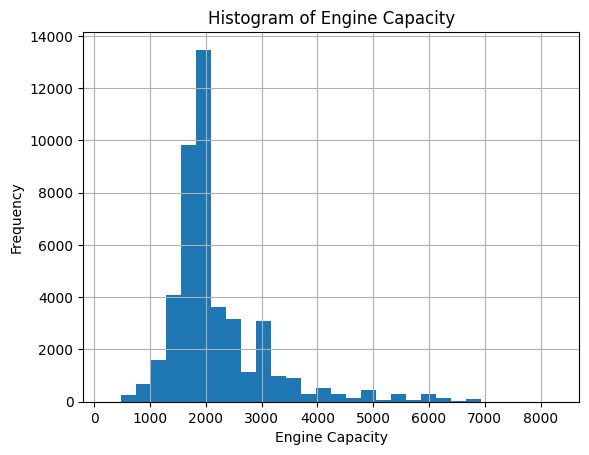

In [11]:
data['engine_capacity'].hist(bins=30)
plt.title('Histogram of Engine Capacity')
plt.xlabel('Engine Capacity')
plt.ylabel('Frequency')
plt.show()


The histogram to illustrates the distribution of engine capacities across a set of vehicles. It shows that the engine capacity data is right-skewed, meaning most vehicles have smaller engines, and fewer vehicles have larger engines. The most frequent engine capacities are under 2000 cc, indicating a predominance of compact and mid-sized cars in the dataset. As engine capacity increases, the number of vehicles decreases, which is visible from the diminishing height of the bars on the right side of the histogram. There's also a noticeable presence of vehicles with engine capacities greater than 5000 cc, though these are uncommon and might represent more specialized vehicles like heavy-duty trucks or high-performance sports cars. Overall, the histogram reflects a diverse range of engine sizes, with a significant skew towards smaller, more economical engines.

### Histogram of co2

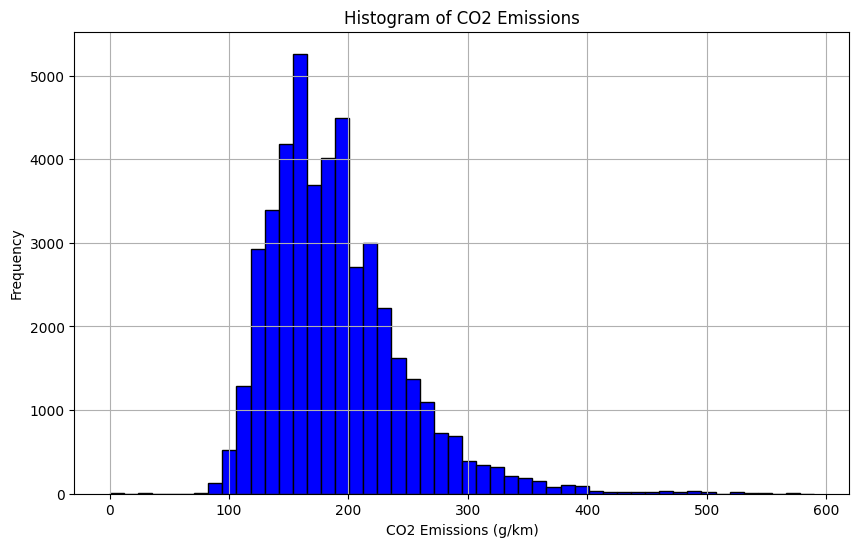

In [12]:
# Plotting the histogram for CO2 emissions
plt.figure(figsize=(10, 6))
plt.hist(data['co2'], bins=50, color='blue', edgecolor='black')
plt.title('Histogram of CO2 Emissions')
plt.xlabel('CO2 Emissions (g/km)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

The histogram visualizes the distribution of CO2 emissions across the dataset. This graph is right-skewed, showing that a large number of vehicles have lower CO2 emissions, with a peak in frequency for vehicles emitting CO2 in the range below 200 grams per kilometer. The distribution reveals that as CO2 emissions increase, the number of vehicles decreases—the tail of the distribution extends toward higher emissions, but such vehicles are less common. The presence of vehicles with emissions over 400 grams per kilometer is notably sparse, which might suggest that these are high-performance or older models that are less efficient in terms of emissions. The overall shape of the histogram indicates that the dataset primarily consists of vehicles with lower CO2 emissions, aligning with modern fuel efficiency standards and environmental regulations that encourage or enforce lower emissions.

### Histogram of NOx emissions

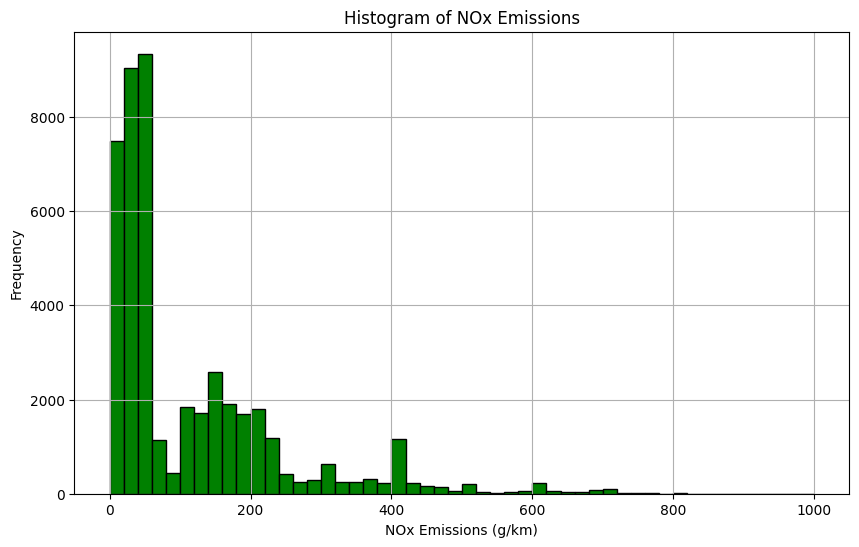

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(data['nox_emissions'].dropna(), bins=50, color='green', edgecolor='black', range=(0, 1000)) # Limiting range to 0-1000 g/km
plt.title('Histogram of NOx Emissions')
plt.xlabel('NOx Emissions (g/km)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


The histogram visualizes the distribution of NOx emissions in the dataset, with the x-axis representing NOx emissions in grams per kilometer and the y-axis showing the frequency of vehicles within various emission ranges. The data shows a right-skewed distribution, where a high frequency of vehicles have low NOx emissions, particularly concentrated at the lower end of the scale. As the NOx emissions increase, the frequency of vehicles drastically decreases, which indicates that higher NOx emissions are much less common in this dataset. The sharp peak near the lower end suggests that most vehicles have emissions well under 200 g/km, aligning with stricter environmental standards. Conversely, the long tail with fewer vehicles towards the higher end of the NOx emission spectrum suggests the presence of some vehicles with significantly higher emissions, which could potentially include older models or those with larger engines. This distribution pattern underscores the emphasis on lower emissions in newer vehicle designs or regulations that target reductions in NOx emissions.

### Histogram for co emission

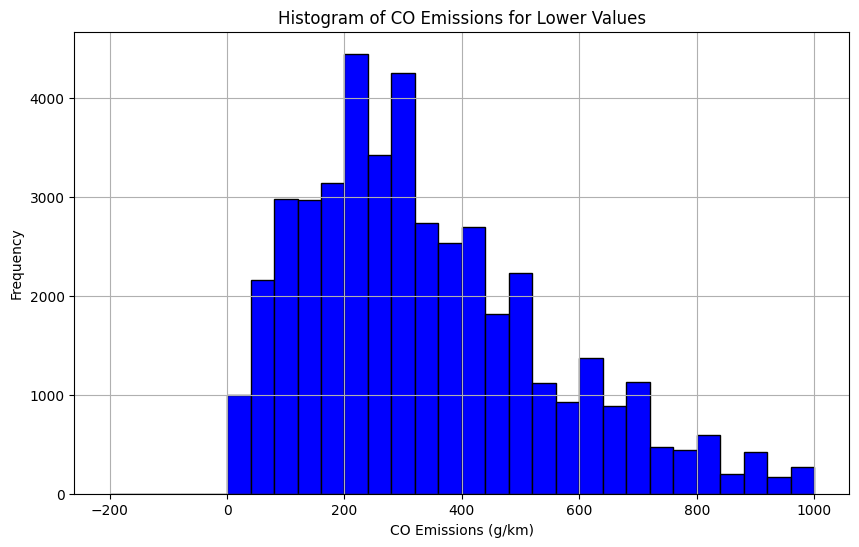

In [14]:
# Filter the 'co_emissions' column to focus on the lower values
lower_co_emissions = data['co_emissions'][data['co_emissions'] <= 1000]
plt.figure(figsize=(10, 6))
plt.hist(lower_co_emissions, bins=30, color='blue', edgecolor='black')
plt.title('Histogram of CO Emissions for Lower Values')
plt.xlabel('CO Emissions (g/km)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


The histogram displays the frequency distribution of CO (carbon monoxide) emissions across a range of vehicles for lower emission values, specifically between 0 to 1000 grams per kilometer (g/km). The chart indicates that the data is skewed to the right, with a higher concentration of vehicles in the lower emissions bracket. The tallest bars, representing the most common CO emission values, fall within the lower end of the range, suggesting that many vehicles have relatively low CO emissions.

### Histogram for noise level

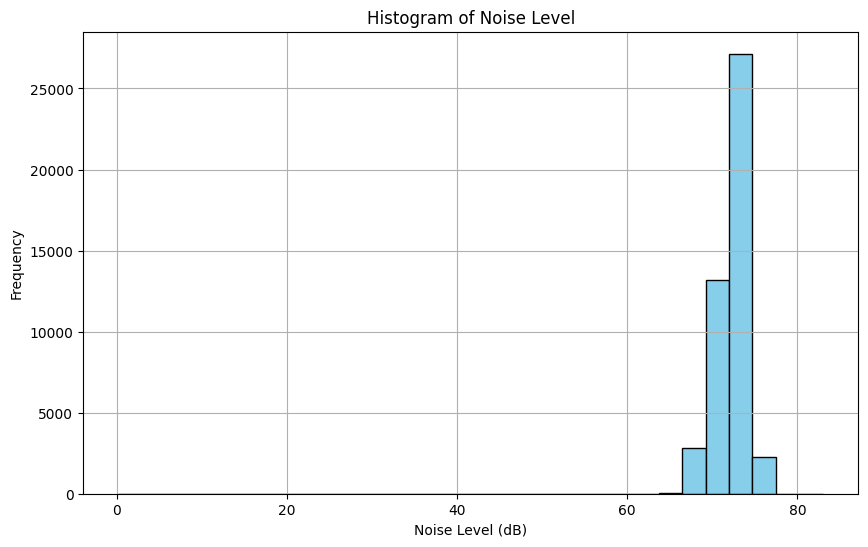

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(data['noise_level'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Noise Level')
plt.xlabel('Noise Level (dB)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

The distribution appears to be unimodal, with the highest frequency centered around the 60 dB mark. The bars to the left and right of this peak are significantly shorter, indicating that fewer vehicles have lower or higher noise levels compared to the central peak. There are very few vehicles with noise levels below 40 dB or above 80 dB, making these ranges relatively rare occurrences in the dataset.

### Bar charts on Categorical columns( manufacturer, fuel_type)

/tmp/ipykernel_66026/3273981254.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=manufacturer_counts.index, x=manufacturer_counts.values, palette="viridis")


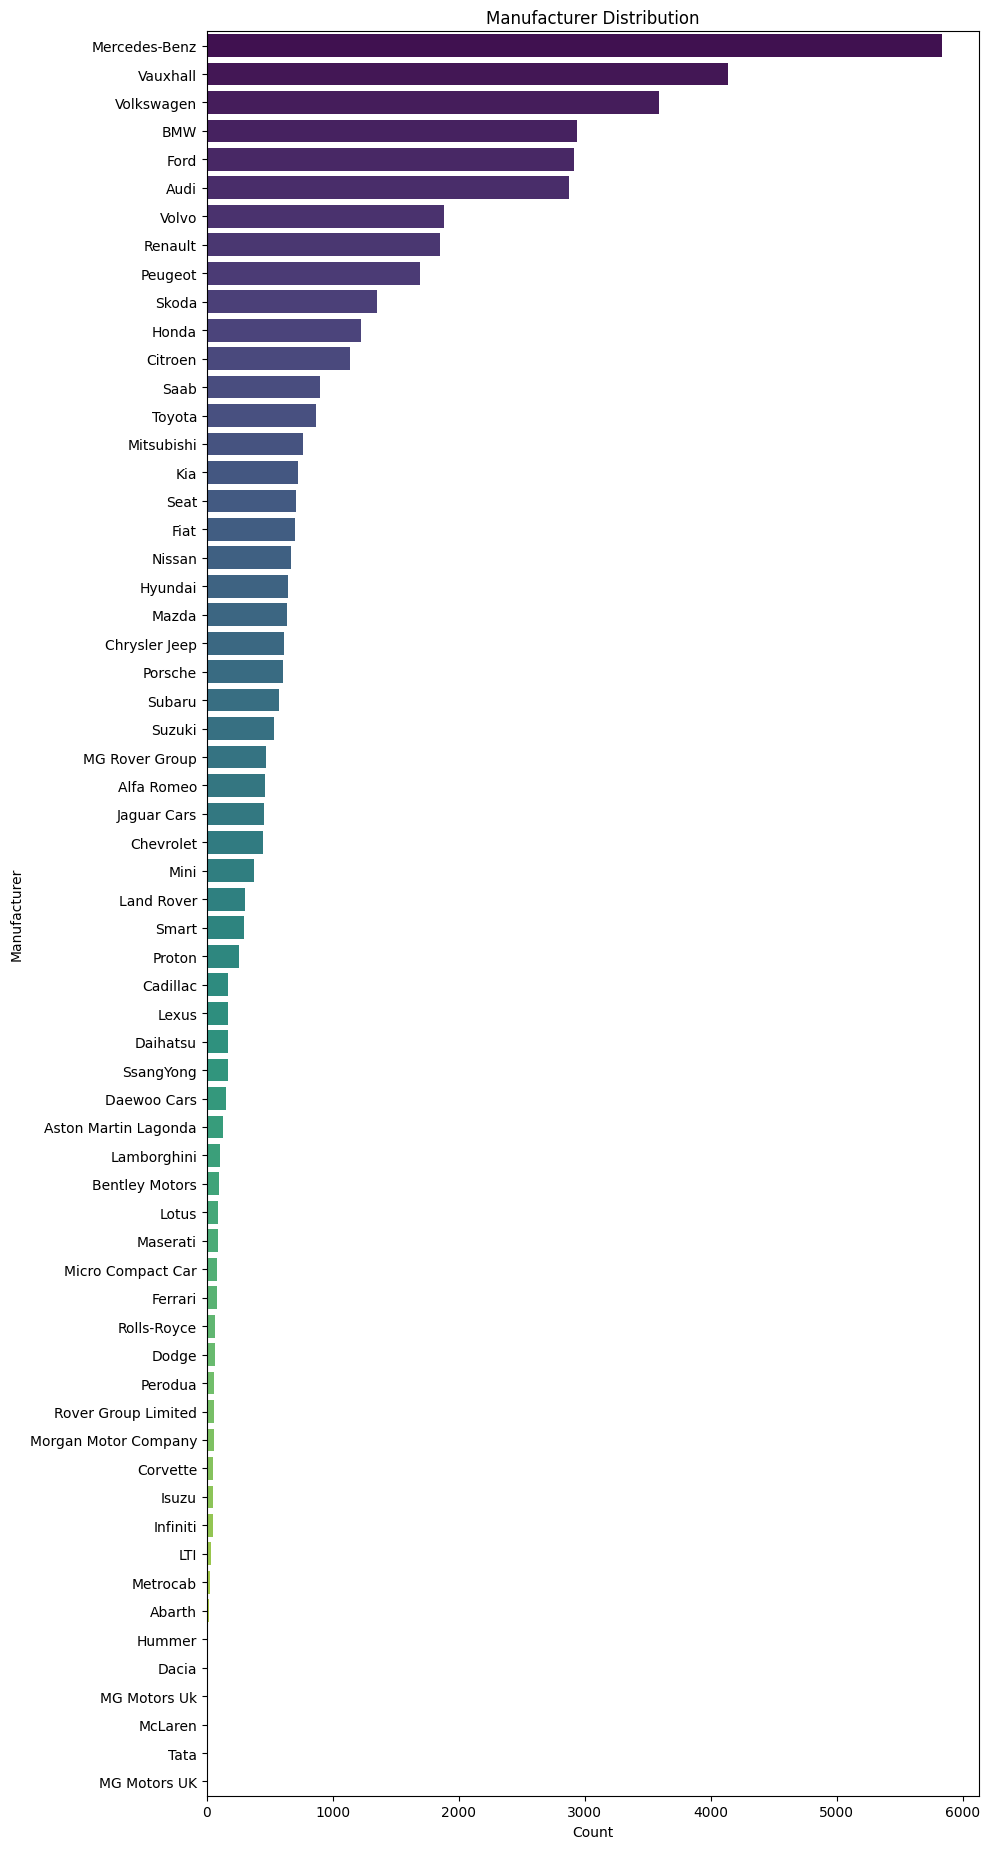

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
# Counting the occurrences of each manufacturer
manufacturer_counts = data['manufacturer'].value_counts()

# Horizontal bar plot
plt.figure(figsize=(10, max(15, len(manufacturer_counts) * 0.3)))  # Dynamic height based on number of manufacturers
sns.barplot(y=manufacturer_counts.index, x=manufacturer_counts.values, palette="viridis")

# Title and labels
plt.title('Manufacturer Distribution')
plt.xlabel('Count')
plt.ylabel('Manufacturer')

# Rotate the y-axis labels to prevent overlap
plt.yticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()


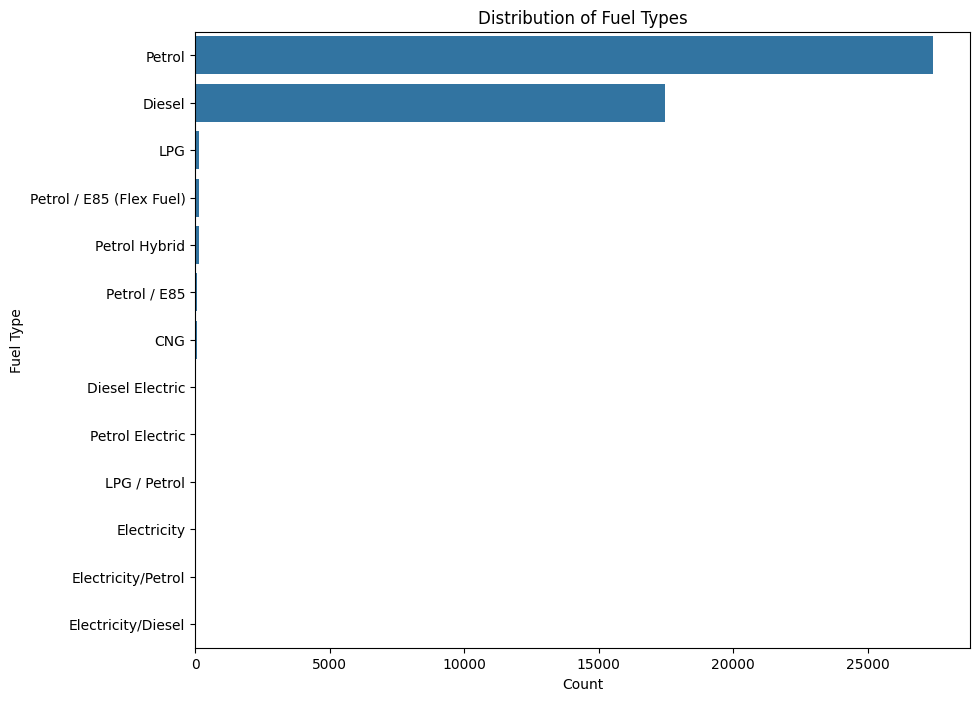

In [17]:
plt.figure(figsize=(10, 8))
sns.countplot(y='fuel_type', data=data, order = data['fuel_type'].value_counts().index)
plt.title('Distribution of Fuel Types')
plt.xlabel('Count')
plt.ylabel('Fuel Type')
plt.show()

The bar chart provides an overview of the distribution of fuel types among vehicles in the dataset. It is apparent that 'Petrol' is the predominant fuel type, followed by 'Diesel', which also represents a substantial portion of the dataset. Other fuel types such as 'LPG', 'Petrol/E85 (Flex Fuel)', and various hybrid and electric combinations are present but in significantly smaller numbers. The 'Petrol Hybrid' and 'Diesel Electric' categories suggest the inclusion of more environmentally friendly vehicles, although they constitute a much smaller fraction compared to traditional fuel types. The diversity of fuel types reflects the range of vehicle technologies and fuel options in the dataset, from conventional combustion engines to more modern and alternative energy vehicles. This distribution is essential for understanding the potential environmental impact and the evolution of vehicle fuel technologies within the dataset's context.

### Scatter plot of co2 over years

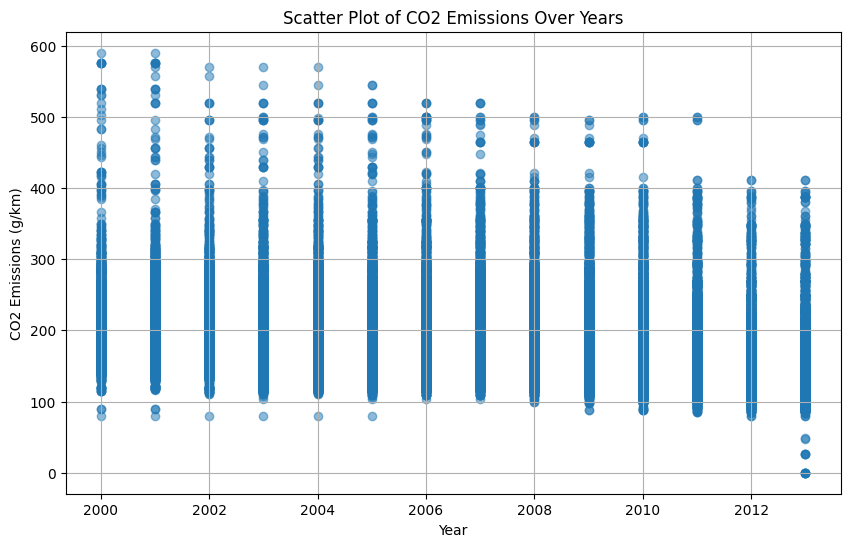

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(data['year'], data['co2'], alpha=0.5)
plt.title('Scatter Plot of CO2 Emissions Over Years')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (g/km)')
plt.grid(True)
plt.show()

The distribution of points across the years does not show a clear trend in CO2 emissions reduction or increase over time. Instead, there is a wide range of emissions for each year, as indicated by the vertical spread of points. This could suggest that while some newer vehicles have lower emissions, the overall decrease in emissions over time is not uniform, and high-emission vehicles are still being produced or are in use. The plot also shows a significant number of vehicles with CO2 emissions clustered in the lower range, especially in later years, which may indicate advancements in vehicle technology and tighter environmental regulations. However, the presence of vehicles with higher emissions across all years suggests that there are still many vehicles on the road that are not as environmentally friendly.

### Histograms for urban_imperial,extra_urban_imperial,combined_imperial

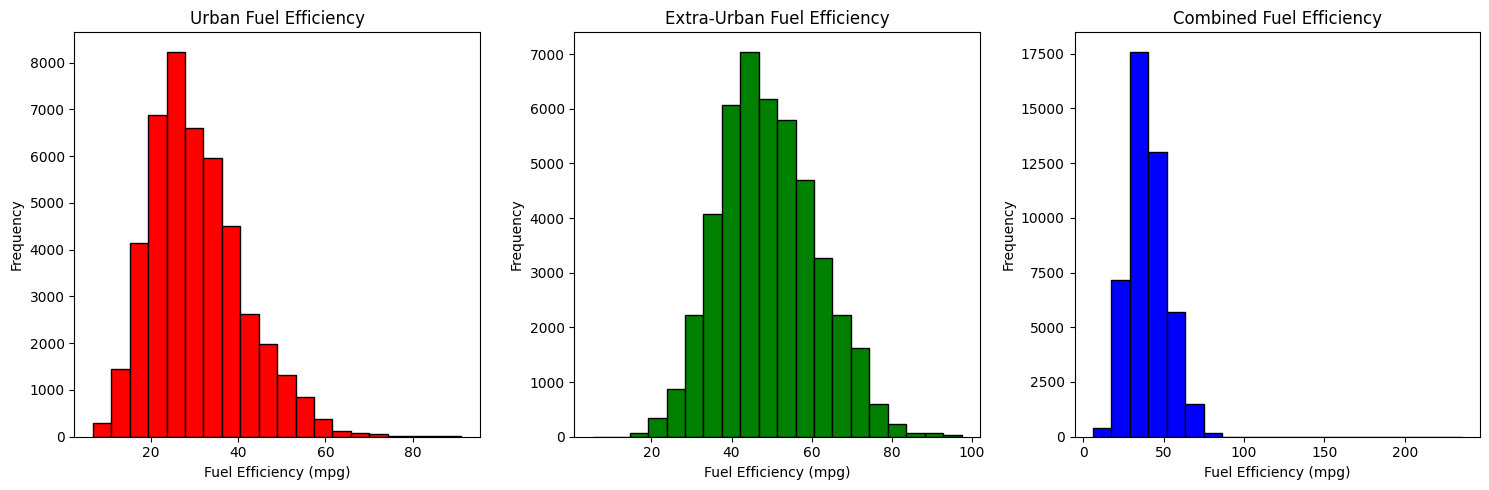

In [19]:
plt.figure(figsize=(15, 5))

# Histogram for urban_imperial
plt.subplot(1, 3, 1)
plt.hist(data['urban_imperial'].dropna(), bins=20, color='red', edgecolor='black')
plt.title('Urban Fuel Efficiency')
plt.xlabel('Fuel Efficiency (mpg)')
plt.ylabel('Frequency')

# Histogram for extra_urban_imperial
plt.subplot(1, 3, 2)
plt.hist(data['extra_urban_imperial'].dropna(), bins=20, color='green', edgecolor='black')
plt.title('Extra-Urban Fuel Efficiency')
plt.xlabel('Fuel Efficiency (mpg)')
plt.ylabel('Frequency')

# Histogram for combined_imperial
plt.subplot(1, 3, 3)
plt.hist(data['combined_imperial'].dropna(), bins=20, color='blue', edgecolor='black')
plt.title('Combined Fuel Efficiency')
plt.xlabel('Fuel Efficiency (mpg)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

The first histogram, in red, shows 'Urban Fuel Efficiency'. It indicates that most vehicles have lower fuel efficiency in urban settings, with the majority of values clustered between 20 and 40 mpg. This is likely due to frequent stops and starts in city driving, which tends to decrease fuel economy.

The second histogram, in green, represents 'Extra-Urban Fuel Efficiency'. The distribution here is more towards the higher mpg values, peaking between 40 and 60 mpg. This suggests that vehicles are more fuel-efficient in extra-urban conditions, such as on highways, where driving is more constant and involves fewer stops.

The third histogram, in blue, for 'Combined Fuel Efficiency', shows a composite distribution of urban and extra-urban driving conditions. The peak of this histogram is broader and shifted towards a higher mpg compared to the urban-only histogram, suggesting better overall efficiency but still less than extra-urban driving. The spread of the combined fuel efficiency is wide, indicating a diverse range of vehicle performances under general driving conditions.


### Histogram for euro_standard

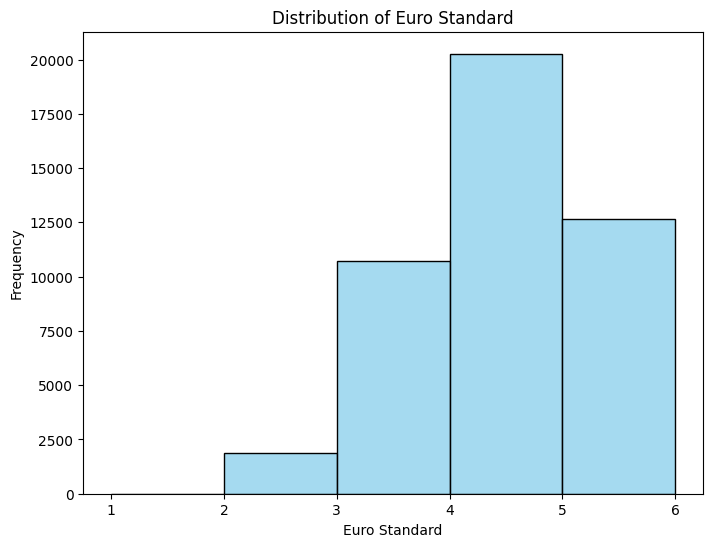

In [20]:
plt.figure(figsize=(8, 6))
sns.histplot(data['euro_standard'].dropna(), kde=False, bins=range(1, data['euro_standard'].max() + 1), color='skyblue', edgecolor='black')
plt.title('Distribution of Euro Standard')
plt.xlabel('Euro Standard')
plt.ylabel('Frequency')
plt.xticks(range(1, data['euro_standard'].max() + 1))
plt.show()

The histogram represents the distribution of the Euro emission standards across a dataset of vehicles. Each bar corresponds to one of the Euro standards, ranging from Euro 1 to Euro 6, and the height of the bar indicates the frequency of vehicles that comply with each standard.

From this histogram, we can observe that Euro 4 has the highest frequency, suggesting that a large proportion of vehicles in the dataset meet the Euro 4 emission requirements. This could indicate that the dataset contains many vehicles manufactured around the time when Euro 4 standards were actively enforced. The lower frequencies of Euro 1 and Euro 2 standards imply that fewer vehicles in the dataset adhere to these older emission standards, which could be due to the phasing out of older vehicles or a preference for newer, cleaner vehicles. Euro 5 and Euro 6 standards have moderate frequencies, potentially reflecting the transition to more stringent emission standards in more recent years.

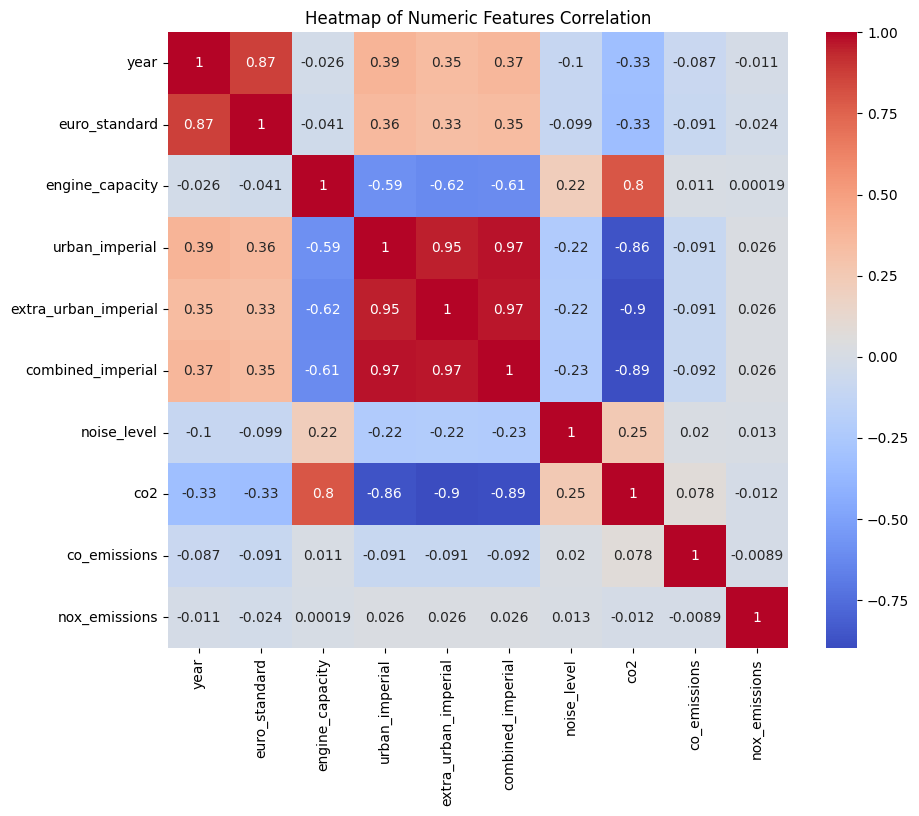

Relevant features to 'co2':
year: -0.3274261117745865
euro_standard: -0.32891277813899233
engine_capacity: 0.7974380700444185
urban_imperial: -0.8614465787106085
extra_urban_imperial: -0.8985201174445209
combined_imperial: -0.8853666093484971
noise_level: 0.2518440587872057

Highly correlated pairs of features:
('year', 'euro_standard')
('urban_imperial', 'extra_urban_imperial')
('urban_imperial', 'combined_imperial')
('urban_imperial', 'co2')
('extra_urban_imperial', 'combined_imperial')
('extra_urban_imperial', 'co2')
('combined_imperial', 'co2')


In [21]:
#Select numeric columns only for correlation analysis
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Calculate the correlation matrix
correlation_matrix = data[numeric_cols].corr()

# Plot a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Heatmap of Numeric Features Correlation')
plt.show()

# Initialize variables for relevant features and multicollinearity checks
relevant_to_target = {}
highly_correlated_pairs = []

# Use a while loop to find features highly correlated with the target 'co2'
i = 0
while i < len(numeric_cols):
    col = numeric_cols[i]
    if col != 'co2':
        corr_with_target = correlation_matrix.at[col, 'co2']
        if abs(corr_with_target) > 0.1:  # Choose a threshold for relevance
            relevant_to_target[col] = corr_with_target
    i += 1

# Use nested while loops to check for multicollinearity
i = 0
while i < len(numeric_cols):
    j = i + 1
    while j < len(numeric_cols):
        col_i, col_j = numeric_cols[i], numeric_cols[j]
        if abs(correlation_matrix.at[col_i, col_j]) > 0.8:  # Choose a threshold for multicollinearity
            highly_correlated_pairs.append((col_i, col_j))
        j += 1
    i += 1

# Print the results
print("Relevant features to 'co2':")
for feature, corr_value in relevant_to_target.items():
    print(f"{feature}: {corr_value}")

print("\nHighly correlated pairs of features:")
for pair in highly_correlated_pairs:
    print(pair)

The heatmap visualizes the correlation matrix of numeric features in a dataset, which quantifies the linear relationship between pairs of features. In this matrix, the color intensity reflects the strength and direction of the correlation. Red tones indicate a positive correlation, where the values of one feature increase with the values of another, while blue tones suggest a negative correlation, indicating an inverse relationship.

From the heatmap, we can deduce several key insights. For example, there's a strong positive correlation between 'urban_imperial', 'extra_urban_imperial', and 'combined_imperial' suggesting that vehicles with higher fuel efficiency in urban settings tend to also be more efficient in extra-urban and overall conditions. The 'euro_standard' also shows a notable positive correlation with 'year', indicating that newer vehicles tend to comply with more stringent emission standards. On the other hand, 'co2' has a high negative correlation with 'urban_imperial', 'extra_urban_imperial', and 'combined_imperial', which means that as fuel efficiency improves, CO2 emissions tend to decrease.

The section below the heatmap provides further detail. The list of relevant features to 'co2' shows 'combined_imperial', 'extra_urban_imperial', and 'urban_imperial' as having the strongest negative correlations, meaning they are inversely related to CO2 emissions and are likely important predictors. The high correlation values close to -0.9 suggest a very strong inverse relationship. Additionally, the listed pairs of features with high multicollinearity, such as ('year', 'euro_standard') and the fuel efficiency metrics among themselves, indicate that these features provide overlapping information which could be problematic in predictive modeling due to redundancy. 

# Machine Learning

# Machine learning algorithms we used for regression tasks include:

1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression
4. Support Vector Regression
5. K-Nearest Neighbors Regression
6. Gradient Boosting Regression
7. AdaBoost Regression
8. Neural Network Regression (Multilayer Perceptron)
9. Gaussian Process Regression
10. Bayesian Regression

In [22]:
# Load the dataset
df = pd.read_csv('cleaned_dataset_imputed.csv')

In [23]:
# data = pd.read_csv('your_dataset.csv')


# 2. Once the dataset is loaded, you can print the columns using the `columns` attribute. This will display a list of the column names in the dataset:


print(data.columns)

Index(['year', 'manufacturer', 'model', 'euro_standard', 'transmission',
       'transmission_type', 'engine_capacity', 'fuel_type', 'urban_imperial',
       'extra_urban_imperial', 'combined_imperial', 'noise_level', 'co2',
       'co_emissions', 'nox_emissions'],
      dtype='object')


In [24]:
numerical_cols_with_few_nans = ['engine_capacity', 'urban_imperial', 'extra_urban_imperial', 
                                'combined_imperial', 'noise_level']

In [25]:
# I have values of different scales make all of them in the range of 0 to 1

from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Assuming your dataframe is stored in a variable called 'df'

# Select the columns you want to scale
columns_to_scale = ['engine_capacity', 'urban_imperial', 'extra_urban_imperial', 
                                'combined_imperial', 'noise_level']

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Perform Min-Max scaling on the selected columns
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Print the updated dataframe
print(df.head())

   year manufacturer      model  euro_standard transmission transmission_type  \
0  2000   Alfa Romeo  145 Range              2           M5            Manual   
1  2000   Alfa Romeo  145 Range              2           M5            Manual   
2  2000   Alfa Romeo  145 Range              2           M5            Manual   
3  2000   Alfa Romeo  146 Range              2           M5            Manual   
4  2000   Alfa Romeo  146 Range              2           M5            Manual   

   engine_capacity fuel_type  urban_imperial  extra_urban_imperial  \
0         0.171991    Petrol        0.220641              0.414130   
1         0.190441    Petrol        0.211151              0.406522   
2         0.218053    Petrol        0.189798              0.406522   
3         0.171991    Petrol        0.215896              0.406522   
4         0.190441    Petrol        0.211151              0.406522   

   combined_imperial  noise_level  co2  co_emissions  nox_emissions  
0           0.124183  

# Firstly we use only 5 numerical column In the next section we use a combination of categorical and numerical values

# LinearRegression

In [26]:
features = ['engine_capacity', 'urban_imperial', 'extra_urban_imperial', 
                                'combined_imperial', 'noise_level']
target = ['co2']


X = df[features].values         # Features
y = df[target].values           # Target 

In [27]:
# Breaking the data into train and test subsets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3)

In [28]:
# Importing 'LinearRegression' through linear_model module

from sklearn.linear_model import LinearRegression  

reg = LinearRegression()         # Instantiate linear regression
reg.fit(X_train, y_train)        # Fit the train data

r2_train_score = reg.score(X_train, y_train)   # Calculating R^2 score for train data

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('Coefficients of Linear Model:', reg.coef_, '\n')
print('Intercept:', reg.intercept_)

R^2 score for train dataset =  0.9029 

Coefficients of Linear Model: [[ 195.13195751   13.37488079 -206.83807635 -228.53874686   60.62213206]] 

Intercept: [217.8286404]


In [29]:
# Finding the predictions of the model for test dataset

y_pred = reg.predict(X_test)

# Evaluating the performance of the model on the test dataset

r2_test_score = reg.score(X_test, y_test)   # Calculating R^2 score for train

print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for test dataset =  0.8997 



## $\color{ForestGreen}{\text{Lasso Regression as a Feature Selection Method}}$

In [30]:
# Importing 'LinearRegression' through linear_model module

from sklearn.linear_model import Lasso  

penalty_factor = [0.0001, 0.0002, 0.0004, 0.0005, 0.001]

for a in penalty_factor:
    lasso = Lasso(alpha=a, max_iter=100000, tol=1e-4)   # Instantiate lasso regression
    lasso.fit(X_train, y_train)        # Fit the train data

    r2_train_score = lasso.score(X_train, y_train)   # Calculating R^2 score for train dataset
    y_pred = lasso.predict(X_test)       # Finding predictions of the model for test dataset
    r2_test_score = lasso.score(X_test, y_test)        # Calculating R^2 score for test dataset

    print('Penalty Factor:', a)
    print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
    print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')
    print('Coefficients of Linear Model:', lasso.coef_, '\n')
    print('Intercept:', lasso.intercept_, '\n******************************')

Penalty Factor: 0.0001
R^2 score for train dataset =  0.9029 

R^2 score for test dataset =  0.8997 

Coefficients of Linear Model: [ 195.13304167   13.07464913 -206.97184461 -227.48007185   60.40572109] 

Intercept: [218.00698573] 
******************************
Penalty Factor: 0.0002
R^2 score for train dataset =  0.9029 

R^2 score for test dataset =  0.8997 

Coefficients of Linear Model: [ 195.13244281   12.73917068 -207.13522215 -226.2670512    60.18813934] 

Intercept: [218.18778932] 
******************************
Penalty Factor: 0.0004
R^2 score for train dataset =  0.9029 

R^2 score for test dataset =  0.8997 

Coefficients of Linear Model: [ 195.13769452   12.0111889  -207.36641483 -223.93497889   59.75062207] 

Intercept: [218.53446994] 
******************************
Penalty Factor: 0.0005
R^2 score for train dataset =  0.9029 

R^2 score for test dataset =  0.8997 

Coefficients of Linear Model: [ 195.1410686    11.64213981 -207.47077951 -222.78387794   59.53164583] 

In

In [31]:
new_df = df[['engine_capacity', 'urban_imperial', 'extra_urban_imperial', 'combined_imperial', 'noise_level','co2']]

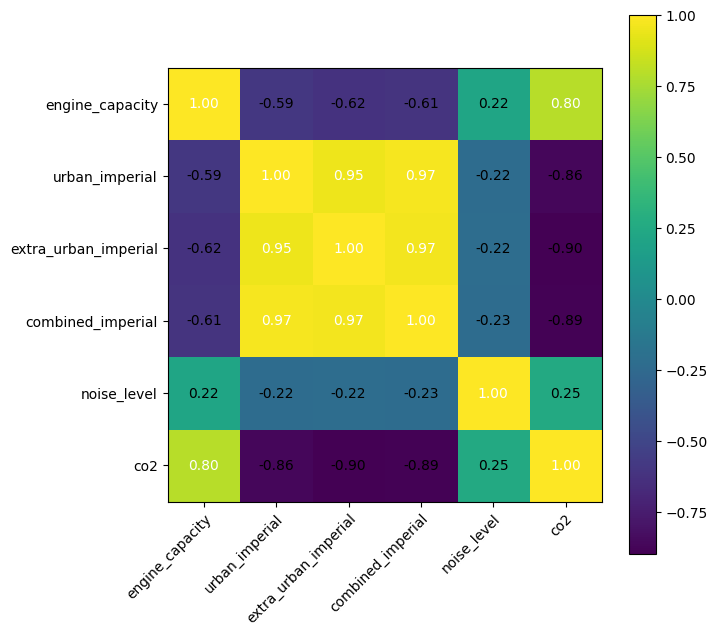

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns 
import mlxtend
from mlxtend.plotting import heatmap

cols = new_df.columns     # List of colmuns of dataframe ca_df

cm = np.corrcoef(df[cols].values.T)     # Calculate Pearson correlation
hm = heatmap(cm, figsize=(7,7), row_names=cols, column_names=cols)  # Represent correlation by a heat map
plt.show()

The results show that the 'urban_imperial', 'extra_urban_imperial', 'combined_imperial' columns have more correlation with co2 while engine_capacity has less correlation and noise_level is of less importance

# Logistic Regression

In [182]:
from sklearn.linear_model import LogisticRegression   # Importing Logistic Regression from sklearn

logreg = LogisticRegression(penalty = 'l2', max_iter = 500, tol=0.0001, C=1.0, fit_intercept=True, solver='lbfgs') # Instantiating logistic regression    # Maximum number of iterations taken for the solvers to converge.



logreg.fit(X_train, y_train)  # Fitting the train data to 'logreg'

# Finding predictions of the logistic regression model for train and test subsets
train_y_pred = logreg.predict_proba(X_train).argmax(axis=0)  # axis=0 
test_y_pred = logreg.predict_proba(X_test).argmax(axis=0)  

/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [183]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Instantiate the logistic regression model
logreg = LogisticRegression()

# Fit the model to the training data
logreg.fit(X_train, y_train)

# Predict the target variable for the train and test datasets
train_y_pred = logreg.predict(X_train)
test_y_pred = logreg.predict(X_test)

# Print the predicted values for train and test datasets
print("Predicted values for the train dataset:")
print(train_y_pred)

print("\nPredicted values for the test dataset:")
print(test_y_pred)

/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Predicted values for the train dataset:
[139 287 214 ... 214 159 214]

Predicted values for the test dataset:
[194 192 287 ... 159 214 192]


In [184]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report

train_score = metrics.accuracy_score(y_train, train_y_pred)   # Compute train accuracy
test_score = metrics.accuracy_score(y_test, test_y_pred)      # Compute test accuracy
train_report = classification_report(y_train, train_y_pred)   # Generate classification report for train data
test_report = classification_report(y_test, test_y_pred)      # Generate classification report for test data

print('Logistic Regression Train Classification Report: \n\n', train_report,'\n\n')
print('Logistic Regression Test Classification Report: \n\n', test_report)

Logistic Regression Train Classification Report: 

               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
          27       0.00      0.00      0.00         3
          48       0.00      0.00      0.00         1
          49       0.00      0.00      0.00         1
          79       0.00      0.00      0.00         2
          80       0.00      0.00      0.00         3
          83       0.00      0.00      0.00         1
          84       0.00      0.00      0.00         2
          85       0.00      0.00      0.00         6
          86       0.00      0.00      0.00         6
          87       0.00      0.00      0.00        13
          88       0.00      0.00      0.00         8
          89       0.00      0.00      0.00        14
          90       0.00      0.00      0.00        13
          91       0.00      0.00      0.00         3
          92       0.00      0.00      0.00        13
          93       0.00      

/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

# Decision Tree Regression

In [35]:
# Constructing a tree regressor with no specified hyperparameters

from sklearn import tree 

tr_reg = tree.DecisionTreeRegressor()
tr_reg.fit(X_train, y_train)

DecisionTreeRegressor()

In [36]:
# Finding the predictions of the tree regressor for train and test subsets

train_y_pred = tr_reg.predict(X_train)
test_y_pred = tr_reg.predict(X_test)

In [37]:
r2_train_score = tr_reg.score(X_train, y_train)   # Calculating R^2 score for train
r2_test_score = tr_reg.score(X_test, y_test)      # Calculating R^2 score for test

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for train dataset =  0.9997 

R^2 score for test dataset =  0.9948 



## $\color{ForestGreen}{\text{Bagged Decision Trees Regressor}}$

In [38]:
# Importing BaggingRegressor from ensemble module

from sklearn.ensemble import BaggingRegressor

# Instantiating the bagged-tree regressor
bag_reg = BaggingRegressor(base_estimator=tree.DecisionTreeRegressor(), n_estimators=100, random_state=3)
bag_reg.fit(X_train, y_train)  # Fitting the train data

/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:509: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)
/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


BaggingRegressor(base_estimator=DecisionTreeRegressor(), n_estimators=100,
                 random_state=3)

In [39]:
# Finding the predictions of bagged-tree regressor for train and test subsets

train_y_pred = bag_reg.predict(X_train)
test_y_pred = bag_reg.predict(X_test)

In [40]:
r2_train_score = bag_reg.score(X_train, y_train)   # Calculating R^2 score for train
r2_test_score = bag_reg.score(X_test, y_test)      # Calculating R^2 score for test

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for train dataset =  0.9992 

R^2 score for test dataset =  0.9962 



## $\color{ForestGreen}{\text{Random Forest Regressor}}$

In [41]:
# Constructing a random forest regressor

from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=1000, random_state=3)  # Instantiating the forest
rf_reg.fit(X_train, y_train)     

/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(n_estimators=1000, random_state=3)

In [42]:
# Finding the predictions of the random forest regressor for train and test subsets

train_y_pred = rf_reg.predict(X_train)
test_y_pred = rf_reg.predict(X_test)

In [43]:
r2_train_score = rf_reg.score(X_train, y_train)   # Calculating R^2 score for train
r2_test_score = rf_reg.score(X_test, y_test)      # Calculating R^2 score for test

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for train dataset =  0.9993 

R^2 score for test dataset =  0.9962 



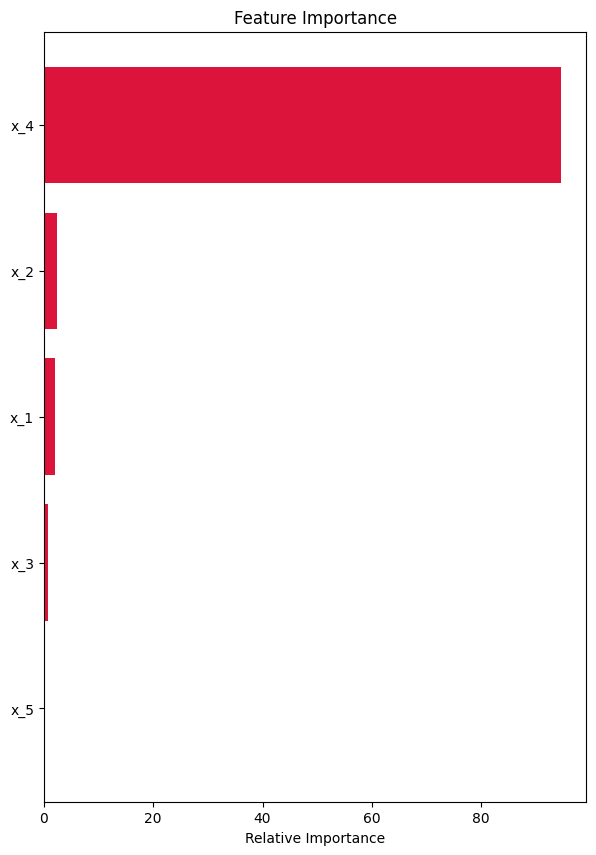

In [44]:
# Calculating the feature importance

feature_importance = rf_reg.feature_importances_
feature_importance = 100.0*(feature_importance/np.sum(feature_importance))

# Displaying the relative feature importance by a horizontal bar chart 

sorted_idx = np.argsort(feature_importance)
pos=np.arange(sorted_idx.shape[0])+0.5
plt.figure(figsize=(7, 10))

plt.title("Feature Importance")
plt.xlabel('Relative Importance')
plt.barh(pos, feature_importance[sorted_idx], color='crimson', align="center")
plt.yticks(pos, np.array(['x_%d' %(i+1) for i in range(20)])[sorted_idx])
plt.show()

The combined_imperial is most dominant feature by far and then urban_imperial and engine_capacity and extra_urban_imperial are the dominant features 

# Support vecrtor Regression

In [45]:



from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Scale the features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the SVR model with desired parameters
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)

# Fit the SVR model to the training data
svr.fit(X_train_scaled, y_train)

# Predict the target variable for the test set
y_pred = svr.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', mse)


# Calculate the R2 score
r2 = r2_score(y_test, y_pred)
print('R2 Score:', r2)




/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mean Squared Error: 185.2895181202801
R2 Score: 0.9427481440209571


In [46]:


from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Scale the features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the KNN Regression model with desired parameters
knn = KNeighborsRegressor(n_neighbors=5)

# Fit the KNN Regression model to the training data
knn.fit(X_train_scaled, y_train)

# Predict the target variable for the test set
y_pred = knn.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Squared Error:', mse)
print('R2 Score:', r2)



Mean Squared Error: 35.16475172110737
R2 Score: 0.9891345861250027


## $\color{ForestGreen}{\text{Gradient Boosting Regressor}}$

In [47]:
# Importing 'GradientBoostingRegressor'

from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor()  # Instantiating GradientBoostingRegressor
gb_reg.fit(X_train, y_train)          # Fitting the train data

/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/ensemble/_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingRegressor()

In [48]:
# Finding the predictions of gradient boosting regressor for train and test subsets

train_y_pred = gb_reg.predict(X_train)
test_y_pred = gb_reg.predict(X_test)

In [49]:
r2_train_score = gb_reg.score(X_train, y_train)   # Calculating R^2 score for train
r2_test_score = gb_reg.score(X_test, y_test)      # Calculating R^2 score for test

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for train dataset =  0.9847 

R^2 score for test dataset =  0.9819 



In [50]:
# Setting new hyperparameters for gradient boosting regressor
gb_params = {'n_estimators': 1000, 'max_depth': 6, 'min_samples_split': 15, 'learning_rate': 0.01}

gb_reg = GradientBoostingRegressor(**gb_params)  # Applying the new hyperparameters
gb_reg.fit(X_train, y_train)                     # Fitting the train data

/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/ensemble/_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingRegressor(learning_rate=0.01, max_depth=6, min_samples_split=15,
                          n_estimators=1000)

In [51]:
# Finding the predictions of gradient boosting regressor for train and test subsets

train_y_pred = gb_reg.predict(X_train)
test_y_pred = gb_reg.predict(X_test)

In [52]:
r2_train_score = gb_reg.score(X_train, y_train)   # Calculating R^2 score for train
r2_test_score = gb_reg.score(X_test, y_test)      # Calculating R^2 score for test

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for train dataset =  0.9942 

R^2 score for test dataset =  0.9917 



## $\color{ForestGreen}{\text{Extreme Gradient Boosting Regressor}}$

In [53]:
# Importing 'xgboost'

import xgboost as xgb 

# Instantiate 'XGBRegressor'
xgb_reg = xgb.XGBRegressor(n_estimators=700, max_depth=6, eta=0.04, subsample=0.8)  

xgb_reg.fit(X_train, y_train)  # Fitting the train data  

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eta=0.04, eval_metric=None,
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=700,
             n_jobs=None, num_parallel_tree=None, ...)

In [54]:
# Finding the predictions of XGBoost regressor for train and test subsets

train_y_pred = xgb_reg.predict(X_train)
test_y_pred = xgb_reg.predict(X_test)

In [55]:
r2_train_score = xgb_reg.score(X_train, y_train)   # Calculating R^2 score for train
r2_test_score = xgb_reg.score(X_test, y_test)      # Calculating R^2 score for test

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for train dataset =  0.9965 

R^2 score for test dataset =  0.9943 



# AdaBoost Regression

In [56]:



from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the AdaBoost Regression model with desired parameters
ada_boost = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, loss='linear')

# Fit the AdaBoost Regression model to the training data
ada_boost.fit(X_train, y_train)

# Predict the target variable for the test set
y_pred = ada_boost.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Squared Error:', mse)
print('R2 Score:', r2)




/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mean Squared Error: 170.24017787742056
R2 Score: 0.9473981785663785


# Gaussian Process Regression

In [57]:



# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, r2_score

# # Initialize the Gaussian Process Regression model with desired parameters
# kernel = RBF(length_scale=1.0)
# gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.1, normalize_y=True)

# # Fit the Gaussian Process Regression model to the training data
# gpr.fit(X_train, y_train)

# # Predict the target variable for the test set
# y_pred, sigma = gpr.predict(X_test, return_std=True)

# # Evaluate the model
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)
# print('Mean Squared Error:', mse)
# print('R2 Score:', r2)



# Bayesian Regression

In [58]:



from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


# Instantiate the Bayesian Regression model
model = BayesianRidge()

# Fit the model to the training data
model.fit(X_train, y_train)

# Predict the target variable for the test data
y_pred = model.predict(X_test)

# Calculate the R-squared score
r2 = r2_score(y_test, y_pred)
print("R-squared score:", r2)





R-squared score: 0.8996680651498575


/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# Neural Network

In [59]:
# Importing basic libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from tqdm.autonotebook import tqdm
import time

# Importing some basic modules in torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import BatchSampler, Dataset, DataLoader

/tmp/ipykernel_66026/2616096769.py:12: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [60]:
def moveTo(obj, device):
    if isinstance(obj, list):
        return [moveTo(x, device) for x in obj]
    elif isinstance(obj, tuple):
        return tuple(moveTo(list(obj), device))
    elif isinstance(obj, set):
        return set(moveTo(list(obj), device))
    elif isinstance(obj, dict):
        to_ret = dict()
        for key, value in obj.items():
            to_ret[moveTo(key, device)] = moveTo(value, device)
        return to_ret
    elif hasattr(obj, "to"):
        return obj.to(device)
    else:
        return obj

In [61]:
def run_epoch(model, optimizer, data_loader, loss_func, device, results, score_funcs, prefix="", desc=None):
    running_loss = []
    y_true = []
    y_pred = []
    start = time.time()
    for inputs, labels in tqdm(data_loader, desc=desc, leave=False): #inputs` represent the input data or features of a batch, and `labels` represent the corresponding true labels or targets for the input data. 
        #Move the batch to the device we are using. 

        inputs = moveTo(inputs, device)
        labels = moveTo(labels, device)
        
        y_hat = model(inputs) #this just computed f_Θ(x(i))

        # Compute loss.
        loss = loss_func(y_hat, labels)
         
        if model.training:  #  is a conditional statement that checks whether the model is currently in training mode.
            loss.backward()  #  to compute the gradients of the loss with respect to the model's parameters
            optimizer.step()
            optimizer.zero_grad()

        #Now we are just grabbing some information we would like to have
        running_loss.append(loss.item())

        if len(score_funcs) > 0 and isinstance(labels, torch.Tensor):
            #moving labels & predictions back to CPU for computing / storing predictions
            labels = labels.detach().cpu().numpy()
            y_hat = y_hat.detach().cpu().numpy()
            #add to predictions so far
            y_true.extend(labels.tolist())   # The line `y_true.extend(labels.tolist())` extends the `y_true` list by appending the elements of the `labels` list to it.
            y_pred.extend(y_hat.tolist())
    #end training epoch
    end = time.time()
    
    y_pred = np.asarray(y_pred)   # The line `y_pred = np.asarray(y_pred)` converts the `y_pred` list to a NumPy array and assigns it back to the variable `y_pred`.
    
    results[prefix + " loss"].append( np.mean(running_loss) )    # This code snippet calculates the mean of the `running_loss` and appends it to the `results[prefix + " loss"]` list.
    for name, score_func in score_funcs.items():
        try:
            results[prefix + " " + name].append( score_func(y_true, y_pred) )  # For regression 
        except:
            results[prefix + " " + name].append(score_func(y_true, np.argmax(y_pred, axis=1))) # For classification
    return end-start #time spent on epoch

In [98]:
def train_simple_network_alt(model, optimizer, loss_func, eta, train_loader, test_loader=None, score_funcs=None, 
                         epochs=50, device="cpu"):
    to_track = ["epoch", "total time", "train loss"]
    if test_loader is not None:
        to_track.append("test loss")
    if score_funcs is not None:
        for eval_score in score_funcs:
            to_track.append("train " + eval_score )
            if test_loader is not None:
                to_track.append("test " + eval_score)
        
    total_train_time = 0              #How long have we spent in the training loop? 
    results = {}
    #Initialize every item with an empty list
    for item in to_track:
        results[item] = []
        
    #Place the model on the correct compute resource (CPU or GPU)
    model.to(device)
    for epoch in tqdm(range(1, epochs+1), desc="Epoch"):
        model = model.train()#Put our model in training mode
        
        total_train_time += run_epoch(model, optimizer, train_loader, loss_func, device, results, score_funcs, 
                                      prefix="train", desc="Training")  
        results["total time"].append( total_train_time )
        results["epoch"].append( epoch )
        
        if test_loader is not None:
            model = model.eval()
            with torch.no_grad():
                run_epoch(model, optimizer, test_loader, loss_func, device, results, score_funcs, prefix="test", 
                          desc="Testing")
                
    return pd.DataFrame.from_dict(results)

In [99]:
class RegressionDataset(Dataset):
        
    def __init__(self, X, y):
        self.X = X.reshape(-1,5)  # This code snippet reshapes the array `X` into a 2-dimensional array with a single column. The `reshape()` function is called on `X` with the argument `-1, 1`, 
        # where `-1` indicates that the length of the dimension should be inferred based on the size of the input array, and `1` specifies the desired number of columns.
        self.y = y.reshape(-1,1)
        
    
    def __getitem__(self, index):
        return torch.tensor(self.X[index,:], dtype=torch.float32), torch.tensor(self.y[index], dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

In [100]:
# We use 'torch.utils.data.random_split' to split the data in pytorch into train and test subsets

data = RegressionDataset(X, y)

train_data, test_data = torch.utils.data.random_split(data, (len(data)-45000, 45000)) 
train_data

In [101]:
train_data_size = len(test_data)
print("Size of train_data subset:", train_data_size)

Size of train_data subset: 45000


In [103]:
# Loading the data through 'DataLoader':

train_loader = DataLoader(train_data , shuffle=True)
test_loader = DataLoader(test_data, shuffle=False)

In [120]:
n_features = 5  # Number of features
n_targets = 1   # Number of targets

n_neurons = 32  # Number of neurons used in hidden layers

eta=0.001       # Learning rate

#del model_2
model_1 = nn.Sequential(
    nn.Linear(n_features,  n_neurons),  # From input layer to hidden layer 1
    nn.Linear(n_neurons,  n_neurons),   # From hidde layer 1 to hidden layer 2
    nn.Linear(n_neurons,  n_neurons),   # From hidde layer 2 to hidden layer 3
    nn.Linear(n_neurons,  n_targets),   # From hidde layer 3 to output layer 
)

optimizer = torch.optim.Adam(model_1.parameters(), lr=eta)   # Adam optimizer 

loss_func = nn.MSELoss()  # We choose the loss function to be MSE

In [121]:
# Training the model and collect the relevant performance metrics 

fc_1_results = train_simple_network_alt(model_1, optimizer, loss_func, eta, train_loader, test_loader, 
                         score_funcs={'accuracy':r2_score}, epochs=200)

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

Training:   0%|          | 0/511 [00:00<?, ?it/s]

Testing:   0%|          | 0/45000 [00:00<?, ?it/s]

Training:   0%|          | 0/511 [00:00<?, ?it/s]

Testing:   0%|          | 0/45000 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/45000 [00:00<?, ?it/s]

Training:   0%|          | 0/511 [00:00<?, ?it/s]

Testing:   0%|          | 0/45000 [00:00<?, ?it/s]

Training:   0%|          | 0/511 [00:00<?, ?it/s]

Testing:   0%|          | 0/45000 [00:00<?, ?it/s]

In [122]:
# Displaying the calculated metrics

fc_1_results

,epoch,total time,train loss,test loss,train accuracy,test accuracy
0,1,0.238406,9806.989400,3430.532672,-2.053865,-0.056033
1,2,0.469734,2691.906847,1737.707434,0.161749,0.465076
2,3,0.705635,1100.396271,548.150432,0.657340,0.831261
3,4,0.934105,398.635634,452.036399,0.875866,0.860848
4,5,1.161714,368.298985,359.422810,0.885313,0.889358
...,...,...,...,...,...,...
195,196,47.202923,330.381479,326.587518,0.897120,0.899465
196,197,47.505464,315.343620,343.508856,0.901803,0.894256
197,198,47.727812,320.593025,326.805150,0.900168,0.899398
198,199,47.955006,336.284794,330.399048,0.895282,0.898292


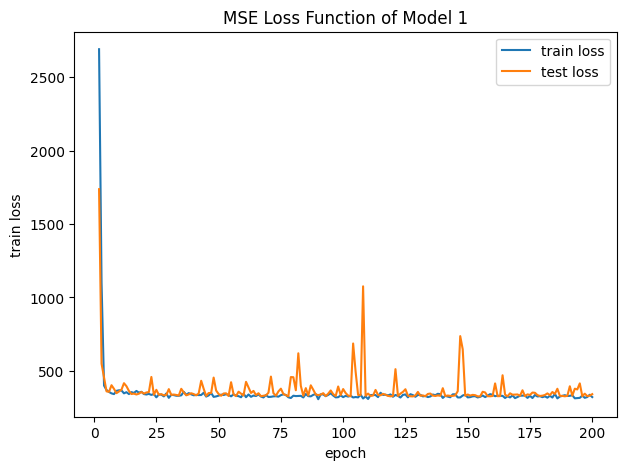

In [123]:
# Plotting the loss function of the fully connected model per epoch:

sns.lineplot(x='epoch', y='train loss', data=fc_1_results[1:], label='train loss')
sns.lineplot(x='epoch', y='test loss', data=fc_1_results[1:], label='test loss')
plt.title('MSE Loss Function of Model 1')
plt.gcf().set_size_inches(7, 5)
plt.show()

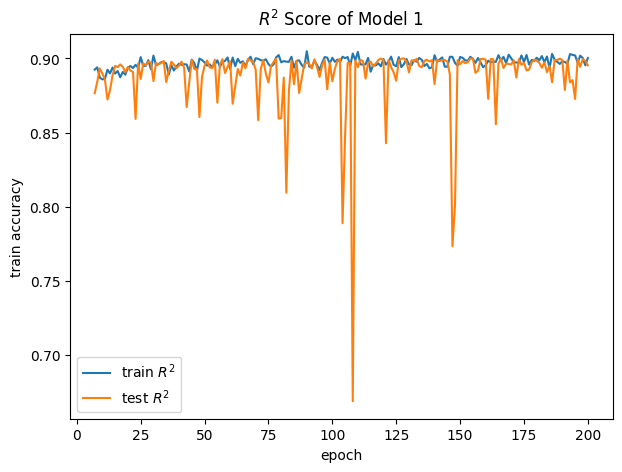

In [124]:
# Plotting the R^2 score of the fully connected model per epoch:

sns.lineplot(x='epoch', y='train accuracy', data=fc_1_results[6:], label=r'train $R^2$')
sns.lineplot(x='epoch', y='test accuracy', data=fc_1_results[6:], label=r'test $R^2$')
plt.title(r'$R^2$ Score of Model 1')
plt.gcf().set_size_inches(7, 5)
plt.show()

# Another NN Model

In [113]:
n_features = 5  # Number of features
n_targets = 1   # Number of targets

n_neurons = 64  # Number of neurons used in hidden layers

eta=0.001       # Learning rate

#del model_2
model_2 = nn.Sequential(
    nn.Linear(n_features,  n_neurons),   # From input layer to hidden layer 1
    nn.Tanh(),                           # Applying tanh activation function
    nn.Linear(n_neurons,  n_neurons),    # From hidde layer 1 to hidden layer 2
    nn.Tanh(),                           # Applying tanh activation function 
    nn.Linear(n_neurons,  n_neurons),    # From hidde layer 2 to hidden layer 3
    nn.Tanh(),                           # Applying tanh activation function
    nn.Linear(n_neurons,  n_targets),    # From hidde layer 3 to output layer 
)

optimizer = torch.optim.Adam(model_2.parameters(), lr=eta)    # Adam optimizer 

loss_func = nn.MSELoss()                 # We choose the loss function to be MSE

In [ ]:
# Training the model and collect the relevant performance metrics 

fc_2_results = train_simple_network_alt(model_2, optimizer, loss_func, eta, train_loader, test_loader, 
                         score_funcs={'accuracy':r2_score}, epochs=200)

In [118]:
# Displaying the calculated metrics

fc_2_results[-10:]

,epoch,total time,train loss,test loss,train accuracy,test accuracy
190,191,88.162624,67.985539,98.460685,0.978830,0.969691
191,192,88.861785,78.171833,120.720487,0.975658,0.962838
192,193,89.420307,80.825734,100.730196,0.974831,0.968992
193,194,90.143303,63.552619,101.815049,0.980210,0.968658
194,195,90.751625,67.836678,107.026900,0.978876,0.967054
195,196,91.264054,66.148161,95.064914,0.979402,0.970736
196,197,91.915540,65.593957,112.401897,0.979574,0.965399
197,198,92.483657,62.041336,98.117056,0.980681,0.969796
198,199,92.799907,65.685650,101.927333,0.979546,0.968623
199,200,93.112948,76.419782,102.309120,0.976203,0.968506


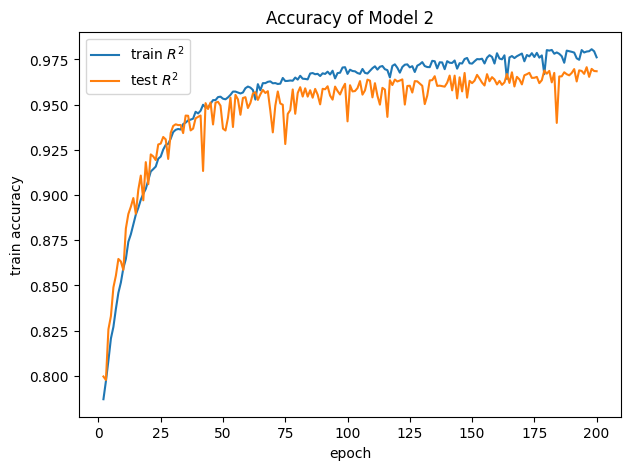

In [119]:
# Plotting the accuracy of model 3:

sns.lineplot(x='epoch', y='train accuracy', data=fc_2_results[1:], label=r'train $R^2$')
sns.lineplot(x='epoch', y='test accuracy', data=fc_2_results[1:], label=r'test $R^2$')
plt.title('Accuracy of Model 2')
plt.gcf().set_size_inches(7, 5)
plt.show()

# Adding the categorical colunns to the current numerical columns

In [125]:
# Converting the categotrical columns into numerics by label encoding

from sklearn.preprocessing import LabelEncoder

# Assuming your categorical column is named 'category_column'
label_encoder = LabelEncoder()
df['manufacturer'] = label_encoder.fit_transform(df['manufacturer'])
df['fuel_type'] = label_encoder.fit_transform(df['fuel_type'])
df['transmission'] = label_encoder.fit_transform(df['transmission'])

In [127]:
df.head

<bound method NDFrame.head of        year  manufacturer          model  euro_standard  transmission  \
0      2000             1      145 Range              2            52   
1      2000             1      145 Range              2            52   
2      2000             1      145 Range              2            52   
3      2000             1      146 Range              2            52   
4      2000             1      146 Range              2            52   
...     ...           ...            ...            ...           ...   
45506  2013            60  New Golf 2013              6            37   
45507  2013            60  New Golf 2013              6            57   
45508  2013            60  New Golf 2013              6            57   
45509  2013            60  New Golf 2013              6            37   
45510  2013            60  New Golf 2013              6            37   

      transmission_type  engine_capacity  fuel_type  urban_imperial  \
0                Manua

In [126]:
features = ['engine_capacity', 'urban_imperial', 'extra_urban_imperial', 
                                'combined_imperial', 'noise_level','manufacturer','fuel_type','transmission']
target = ['co2']


X = df[features].values         # Features
y = df[target].values           # Target 

In [128]:
# Breaking the data into train and test subsets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=3)

In [129]:
# Importing 'LinearRegression' through linear_model module

from sklearn.linear_model import LinearRegression  

reg = LinearRegression()         # Instantiate linear regression
reg.fit(X_train, y_train)        # Fit the train data

r2_train_score = reg.score(X_train, y_train)   # Calculating R^2 score for train data

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('Coefficients of Linear Model:', reg.coef_, '\n')
print('Intercept:', reg.intercept_)

R^2 score for train dataset =  0.9041 

Coefficients of Linear Model: [[ 1.91385439e+02  5.80600842e+00 -2.05838965e+02 -2.40714066e+02
   5.08279866e+01  5.10539718e-02 -5.84803671e-01  3.56797845e-03]] 

Intercept: [231.89190787]


In [130]:
# Finding the predictions of the model for test dataset

y_pred = reg.predict(X_test)

# Evaluating the performance of the model on the test dataset

r2_test_score = reg.score(X_test, y_test)   # Calculating R^2 score for train

print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for test dataset =  0.9006 



## $\color{ForestGreen}{\text{Lasso Regression as a Feature Selection Method}}$

In [131]:
# Importing 'LinearRegression' through linear_model module

from sklearn.linear_model import Lasso  

penalty_factor = [0.0001, 0.0002, 0.0004, 0.0005, 0.001]

for a in penalty_factor:
    lasso = Lasso(alpha=a, max_iter=100000, tol=1e-4)   # Instantiate lasso regression
    lasso.fit(X_train, y_train)        # Fit the train data

    r2_train_score = lasso.score(X_train, y_train)   # Calculating R^2 score for train dataset
    y_pred = lasso.predict(X_test)       # Finding predictions of the model for test dataset
    r2_test_score = lasso.score(X_test, y_test)        # Calculating R^2 score for test dataset

    print('Penalty Factor:', a)
    print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
    print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')
    print('Coefficients of Linear Model:', lasso.coef_, '\n')
    print('Intercept:', lasso.intercept_, '\n******************************')

Penalty Factor: 0.0001
R^2 score for train dataset =  0.9041 

R^2 score for test dataset =  0.9006 

Coefficients of Linear Model: [ 1.91385384e+02  5.51957626e+00 -2.05976389e+02 -2.39688894e+02
  5.05999318e+01  5.10489361e-02 -5.84919078e-01  3.61874539e-03] 

Intercept: [232.08212828] 
******************************
Penalty Factor: 0.0002
R^2 score for train dataset =  0.9041 

R^2 score for test dataset =  0.9006 

Coefficients of Linear Model: [ 1.91382974e+02  5.18443605e+00 -2.06137153e+02 -2.38497265e+02
  5.03689207e+01  5.10409893e-02 -5.85118617e-01  3.67173988e-03] 

Intercept: [232.27598365] 
******************************
Penalty Factor: 0.0004
R^2 score for train dataset =  0.9041 

R^2 score for test dataset =  0.9006 

Coefficients of Linear Model: [ 1.91381957e+02  4.47046092e+00 -2.06396796e+02 -2.36160626e+02
  4.99056591e+01  5.10277196e-02 -5.85563915e-01  3.77275321e-03] 

Intercept: [232.65402388] 
******************************
Penalty Factor: 0.0005
R^2 scor

In [132]:
new_Cat_Num_df = df[['engine_capacity', 'urban_imperial', 'extra_urban_imperial', 'combined_imperial', 'noise_level','manufacturer','fuel_type','transmission','co2']]

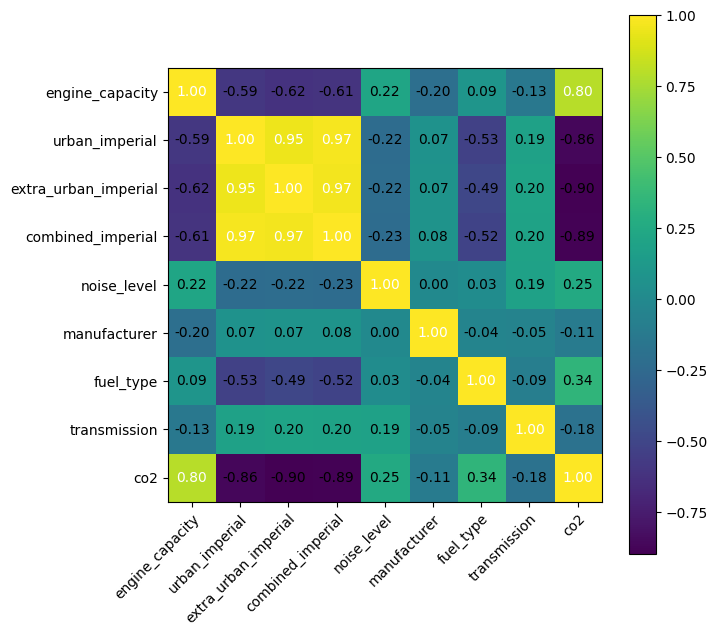

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns 
import mlxtend
from mlxtend.plotting import heatmap

cols = new_Cat_Num_df.columns     # List of colmuns of dataframe ca_df

cm = np.corrcoef(df[cols].values.T)     # Calculate Pearson correlation
hm = heatmap(cm, figsize=(7,7), row_names=cols, column_names=cols)  # Represent correlation by a heat map
plt.show()

The results show that the 'urban_imperial', 'extra_urban_imperial', 'combined_imperial' columns have more correlation with co2 while engine_capacity has less correlation and noise_level is of less importance

# Logistic Regression

In [134]:
from sklearn.linear_model import LogisticRegression   # Importing Logistic Regression from sklearn

logreg = LogisticRegression(penalty = 'l2', max_iter = 500, tol=0.0001, C=1.0, fit_intercept=True, solver='lbfgs') # Instantiating logistic regression    # Maximum number of iterations taken for the solvers to converge.



logreg.fit(X_train, y_train)  # Fitting the train data to 'logreg'

# Finding predictions of the logistic regression model for train and test subsets
train_y_pred = logreg.predict_proba(X_train).argmax(axis=1)   
test_y_pred = logreg.predict_proba(X_test).argmax(axis=1)  

/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [135]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report

train_score = metrics.accuracy_score(y_train, train_y_pred)   # Compute train accuracy
test_score = metrics.accuracy_score(y_test, test_y_pred)      # Compute test accuracy
train_report = classification_report(y_train, train_y_pred)   # Generate classification report for train data
test_report = classification_report(y_test, test_y_pred)      # Generate classification report for test data

print('Logistic Regression Train Classification Report: \n\n', train_report,'\n\n')
print('Logistic Regression Test Classification Report: \n\n', test_report)

Logistic Regression Train Classification Report: 

               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         0
          25       0.00      0.00      0.00         0
          27       0.00      0.00      0.00         3
          32       0.00      0.00      0.00         0
          36       0.00      0.00      0.00         0
          39       0.00      0.00      0.00         0
          42       0.00      0.00      0.00         0
          48       0.00      0.00      0.00         1
          49       0.00      0.00      0.00         1
          52       0.00      0.00      0.00         0
          57       0.00      0.00      0.00         0
          62       0.00      0.00      0.00         0
          63       0.00      0.00      0.00         0
          68       0.00      

/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(res

# Decision Tree Regression

In [136]:
# Constructing a tree regressor with no specified hyperparameters

from sklearn import tree 

tr_reg = tree.DecisionTreeRegressor()
tr_reg.fit(X_train, y_train)

DecisionTreeRegressor()

In [137]:
# Finding the predictions of the tree regressor for train and test subsets

train_y_pred = tr_reg.predict(X_train)
test_y_pred = tr_reg.predict(X_test)

In [138]:
r2_train_score = tr_reg.score(X_train, y_train)   # Calculating R^2 score for train
r2_test_score = tr_reg.score(X_test, y_test)      # Calculating R^2 score for test

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for train dataset =  0.9997 

R^2 score for test dataset =  0.9972 



## $\color{ForestGreen}{\text{Bagged Decision Trees Regressor}}$

In [140]:
# Importing BaggingRegressor from ensemble module

from sklearn.ensemble import BaggingRegressor

# Instantiating the bagged-tree regressor
bag_reg = BaggingRegressor(base_estimator=tree.DecisionTreeRegressor(), n_estimators=100, random_state=3)
bag_reg.fit(X_train, y_train)  # Fitting the train data

/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/ensemble/_bagging.py:509: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)
/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


BaggingRegressor(base_estimator=DecisionTreeRegressor(), n_estimators=100,
                 random_state=3)

In [141]:
# Finding the predictions of bagged-tree regressor for train and test subsets

train_y_pred = bag_reg.predict(X_train)
test_y_pred = bag_reg.predict(X_test)

In [142]:
r2_train_score = bag_reg.score(X_train, y_train)   # Calculating R^2 score for train
r2_test_score = bag_reg.score(X_test, y_test)      # Calculating R^2 score for test

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for train dataset =  0.9995 

R^2 score for test dataset =  0.9982 



## $\color{ForestGreen}{\text{Random Forest Regressor}}$

In [143]:
# Constructing a random forest regressor

from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=1000, random_state=3)  # Instantiating the forest
rf_reg.fit(X_train, y_train)     

/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(n_estimators=1000, random_state=3)

In [144]:
# Finding the predictions of the random forest regressor for train and test subsets

train_y_pred = rf_reg.predict(X_train)
test_y_pred = rf_reg.predict(X_test)

In [145]:
r2_train_score = rf_reg.score(X_train, y_train)   # Calculating R^2 score for train
r2_test_score = rf_reg.score(X_test, y_test)      # Calculating R^2 score for test

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for train dataset =  0.9995 

R^2 score for test dataset =  0.9982 



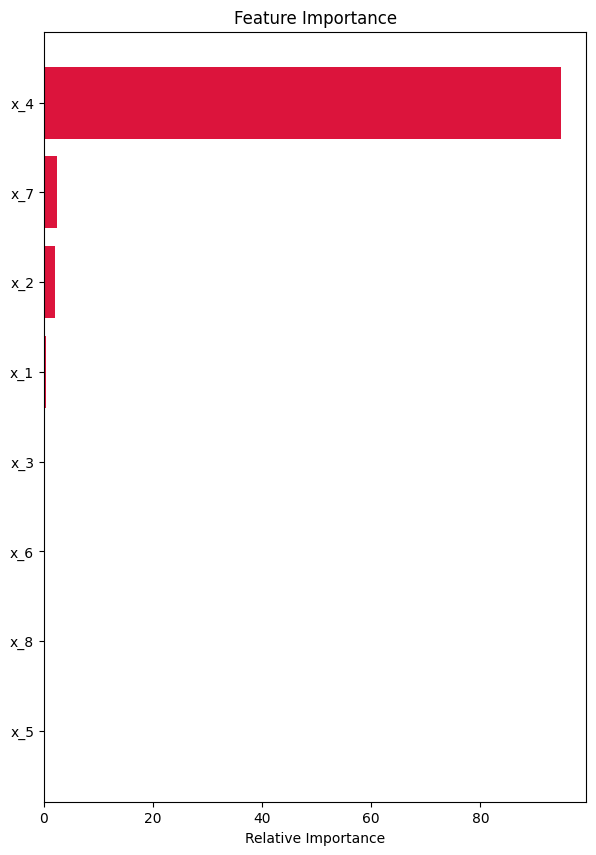

In [146]:
# Calculating the feature importance

feature_importance = rf_reg.feature_importances_
feature_importance = 100.0*(feature_importance/np.sum(feature_importance))

# Displaying the relative feature importance by a horizontal bar chart 

sorted_idx = np.argsort(feature_importance)
pos=np.arange(sorted_idx.shape[0])+0.5
plt.figure(figsize=(7, 10))

plt.title("Feature Importance")
plt.xlabel('Relative Importance')
plt.barh(pos, feature_importance[sorted_idx], color='crimson', align="center")
plt.yticks(pos, np.array(['x_%d' %(i+1) for i in range(20)])[sorted_idx])
plt.show()


the combined_imperial is most dominant feature by far and then fuel_type and urban_imperial and engine_capacity are importannt features. 

# Support vecrtor Regression

In [147]:



from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Scale the features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the SVR model with desired parameters
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)

# Fit the SVR model to the training data
svr.fit(X_train_scaled, y_train)

# Predict the target variable for the test set
y_pred = svr.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print('Mean Squared Error:', mse)


# Calculate the R2 score
r2 = r2_score(y_test, y_pred)
print('R2 Score:', r2)




/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mean Squared Error: 171.64273356349577
R2 Score: 0.946964808578932


# KNN regressor

In [148]:


from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Scale the features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the KNN Regression model with desired parameters
knn = KNeighborsRegressor(n_neighbors=5)

# Fit the KNN Regression model to the training data
knn.fit(X_train_scaled, y_train)

# Predict the target variable for the test set
y_pred = knn.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Squared Error:', mse)
print('R2 Score:', r2)



Mean Squared Error: 26.257896587080708
R2 Score: 0.9918866791334614


## $\color{ForestGreen}{\text{Gradient Boosting Regressor}}$

In [149]:
# Importing 'GradientBoostingRegressor'

from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor()  # Instantiating GradientBoostingRegressor
gb_reg.fit(X_train, y_train)          # Fitting the train data

/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/ensemble/_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingRegressor()

In [150]:
# Finding the predictions of gradient boosting regressor for train and test subsets

train_y_pred = gb_reg.predict(X_train)
test_y_pred = gb_reg.predict(X_test)

In [151]:
r2_train_score = gb_reg.score(X_train, y_train)   # Calculating R^2 score for train
r2_test_score = gb_reg.score(X_test, y_test)      # Calculating R^2 score for test

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for train dataset =  0.995 

R^2 score for test dataset =  0.9942 



In [152]:
# Setting new hyperparameters for gradient boosting regressor
gb_params = {'n_estimators': 1000, 'max_depth': 6, 'min_samples_split': 15, 'learning_rate': 0.01}

gb_reg = GradientBoostingRegressor(**gb_params)  # Applying the new hyperparameters
gb_reg.fit(X_train, y_train)                     # Fitting the train data

/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/ensemble/_gb.py:424: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GradientBoostingRegressor(learning_rate=0.01, max_depth=6, min_samples_split=15,
                          n_estimators=1000)

In [153]:
# Finding the predictions of gradient boosting regressor for train and test subsets

train_y_pred = gb_reg.predict(X_train)
test_y_pred = gb_reg.predict(X_test)

In [154]:
r2_train_score = gb_reg.score(X_train, y_train)   # Calculating R^2 score for train
r2_test_score = gb_reg.score(X_test, y_test)      # Calculating R^2 score for test

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for train dataset =  0.9984 

R^2 score for test dataset =  0.9976 



## $\color{ForestGreen}{\text{Extreme Gradient Boosting Regressor}}$

In [155]:
# Importing 'xgboost'

import xgboost as xgb 

# Instantiate 'XGBRegressor'
xgb_reg = xgb.XGBRegressor(n_estimators=700, max_depth=6, eta=0.04, subsample=0.8)  

xgb_reg.fit(X_train, y_train)  # Fitting the train data  

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eta=0.04, eval_metric=None,
             feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=700,
             n_jobs=None, num_parallel_tree=None, ...)

In [156]:
# Finding the predictions of XGBoost regressor for train and test subsets

train_y_pred = xgb_reg.predict(X_train)
test_y_pred = xgb_reg.predict(X_test)

In [157]:
r2_train_score = xgb_reg.score(X_train, y_train)   # Calculating R^2 score for train
r2_test_score = xgb_reg.score(X_test, y_test)      # Calculating R^2 score for test

print('R^2 score for train dataset = ', round(r2_train_score, 4), '\n')
print('R^2 score for test dataset = ', round(r2_test_score, 4), '\n')

R^2 score for train dataset =  0.9989 

R^2 score for test dataset =  0.998 



# AdaBoost Regression

In [158]:



from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the AdaBoost Regression model with desired parameters
ada_boost = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, loss='linear')

# Fit the AdaBoost Regression model to the training data
ada_boost.fit(X_train, y_train)

# Predict the target variable for the test set
y_pred = ada_boost.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Squared Error:', mse)
print('R2 Score:', r2)




/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Mean Squared Error: 170.03976713876636
R2 Score: 0.9474601026669023


# Gaussian Process Regression

In [159]:



# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, r2_score

# # Initialize the Gaussian Process Regression model with desired parameters
# kernel = RBF(length_scale=1.0)
# gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.1, normalize_y=True)

# # Fit the Gaussian Process Regression model to the training data
# gpr.fit(X_train, y_train)

# # Predict the target variable for the test set
# y_pred, sigma = gpr.predict(X_test, return_std=True)

# # Evaluate the model
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)
# print('Mean Squared Error:', mse)
# print('R2 Score:', r2)




# Bayesian Regression

In [160]:


from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


# Instantiate the Bayesian Regression model
model = BayesianRidge()

# Fit the model to the training data
model.fit(X_train, y_train)

# Predict the target variable for the test data
y_pred = model.predict(X_test)

# Calculate the R-squared score
r2 = r2_score(y_test, y_pred)
print("R-squared score:", r2)


R-squared score: 0.9005753882408055


/home/kianoush/Desktop/kianoush/test/lib/python3.10/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# Neural Network

In [161]:
# Importing basic libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from tqdm.autonotebook import tqdm
import time

# Importing some basic modules in torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import BatchSampler, Dataset, DataLoader

In [162]:
def moveTo(obj, device):
    if isinstance(obj, list):
        return [moveTo(x, device) for x in obj]
    elif isinstance(obj, tuple):
        return tuple(moveTo(list(obj), device))
    elif isinstance(obj, set):
        return set(moveTo(list(obj), device))
    elif isinstance(obj, dict):
        to_ret = dict()
        for key, value in obj.items():
            to_ret[moveTo(key, device)] = moveTo(value, device)
        return to_ret
    elif hasattr(obj, "to"):
        return obj.to(device)
    else:
        return obj

In [163]:
def run_epoch(model, optimizer, data_loader, loss_func, device, results, score_funcs, prefix="", desc=None):
    running_loss = []
    y_true = []
    y_pred = []
    start = time.time()
    for inputs, labels in tqdm(data_loader, desc=desc, leave=False): #inputs` represent the input data or features of a batch, and `labels` represent the corresponding true labels or targets for the input data. 
        #Move the batch to the device we are using. 

        inputs = moveTo(inputs, device)
        labels = moveTo(labels, device)
        
        y_hat = model(inputs) #this just computed f_Θ(x(i))

        # Compute loss.
        loss = loss_func(y_hat, labels)
         
        if model.training:  #  is a conditional statement that checks whether the model is currently in training mode.
            loss.backward()  #  to compute the gradients of the loss with respect to the model's parameters
            optimizer.step()
            optimizer.zero_grad()

        #Now we are just grabbing some information we would like to have
        running_loss.append(loss.item())

        if len(score_funcs) > 0 and isinstance(labels, torch.Tensor):
            #moving labels & predictions back to CPU for computing / storing predictions
            labels = labels.detach().cpu().numpy()
            y_hat = y_hat.detach().cpu().numpy()
            #add to predictions so far
            y_true.extend(labels.tolist())   # The line `y_true.extend(labels.tolist())` extends the `y_true` list by appending the elements of the `labels` list to it.
            y_pred.extend(y_hat.tolist())
    #end training epoch
    end = time.time()
    
    y_pred = np.asarray(y_pred)   # The line `y_pred = np.asarray(y_pred)` converts the `y_pred` list to a NumPy array and assigns it back to the variable `y_pred`.
    
    results[prefix + " loss"].append( np.mean(running_loss) )    # This code snippet calculates the mean of the `running_loss` and appends it to the `results[prefix + " loss"]` list.
    for name, score_func in score_funcs.items():
        try:
            results[prefix + " " + name].append( score_func(y_true, y_pred) )  # For regression 
        except:
            results[prefix + " " + name].append(score_func(y_true, np.argmax(y_pred, axis=1))) # For classification
    return end-start #time spent on epoch

In [164]:
def train_simple_network_alt(model, optimizer, loss_func, eta, train_loader, test_loader=None, score_funcs=None, 
                         epochs=50, device="cpu"):
    to_track = ["epoch", "total time", "train loss"]
    if test_loader is not None:
        to_track.append("test loss")
    if score_funcs is not None:
        for eval_score in score_funcs:
            to_track.append("train " + eval_score )
            if test_loader is not None:
                to_track.append("test " + eval_score)
        
    total_train_time = 0              #How long have we spent in the training loop? 
    results = {}
    #Initialize every item with an empty list
    for item in to_track:
        results[item] = []
        
    #Place the model on the correct compute resource (CPU or GPU)
    model.to(device)
    for epoch in tqdm(range(1, epochs+1), desc="Epoch"):
        model = model.train()#Put our model in training mode
        
        total_train_time += run_epoch(model, optimizer, train_loader, loss_func, device, results, score_funcs, 
                                      prefix="train", desc="Training")  
        results["total time"].append( total_train_time )
        results["epoch"].append( epoch )
        
        if test_loader is not None:
            model = model.eval()
            with torch.no_grad():
                run_epoch(model, optimizer, test_loader, loss_func, device, results, score_funcs, prefix="test", 
                          desc="Testing")
                
    return pd.DataFrame.from_dict(results)

In [166]:
class RegressionDataset(Dataset):
        
    def __init__(self, X, y):
        self.X = X.reshape(-1,8)  # This code snippet reshapes the array `X` into a 2-dimensional array with a single column. The `reshape()` function is called on `X` with the argument `-1, 1`, 
        # where `-1` indicates that the length of the dimension should be inferred based on the size of the input array, and `1` specifies the desired number of columns.
        self.y = y.reshape(-1,1)
        
    
    def __getitem__(self, index):
        return torch.tensor(self.X[index,:], dtype=torch.float32), torch.tensor(self.y[index], dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

In [167]:
# We use 'torch.utils.data.random_split' to split the data in pytorch into train and test subsets

data = RegressionDataset(X, y)

train_data, test_data = torch.utils.data.random_split(data, (len(data)-45000, 45000)) 
train_data

In [168]:
train_data_size = len(test_data)
print("Size of train_data subset:", train_data_size)

Size of train_data subset: 45000


In [169]:
# Loading the data through 'DataLoader':

train_loader = DataLoader(train_data , shuffle=True)
test_loader = DataLoader(test_data, shuffle=False)

In [170]:
n_features = 8  # Number of features
n_targets = 1   # Number of targets

n_neurons = 32  # Number of neurons used in hidden layers

eta=0.001       # Learning rate

#del model_1
model_1 = nn.Sequential(
    nn.Linear(n_features,  n_neurons),  # From input layer to hidden layer 1
    nn.Linear(n_neurons,  n_neurons),   # From hidde layer 1 to hidden layer 2
    nn.Linear(n_neurons,  n_neurons),   # From hidde layer 2 to hidden layer 3
    nn.Linear(n_neurons,  n_targets),   # From hidde layer 3 to output layer 
)

optimizer = torch.optim.Adam(model_1.parameters(), lr=eta)   # Adam optimizer 

loss_func = nn.MSELoss()  # We choose the loss function to be MSE

In [ ]:
# Training the model and collect the relevant performance metrics 

fc_1_results = train_simple_network_alt(model_1, optimizer, loss_func, eta, train_loader, test_loader, 
                         score_funcs={'accuracy':r2_score}, epochs=200)

In [172]:
# Displaying the calculated metrics

fc_1_results

,epoch,total time,train loss,test loss,train accuracy,test accuracy
0,1,0.260181,9203.468510,6939.049916,-2.077528,-1.134392
1,2,0.489904,6353.530065,5271.690250,-1.124543,-0.621526
2,3,0.716558,5119.912462,4648.633817,-0.712036,-0.429880
3,4,0.986380,4600.952473,4734.020880,-0.538503,-0.456144
4,5,1.216349,4270.823478,3967.134131,-0.428111,-0.220256
...,...,...,...,...,...,...
195,196,46.012787,317.922145,386.593209,0.893691,0.881087
196,197,46.229026,327.670371,355.479940,0.890431,0.890657
197,198,46.445392,319.351444,405.667698,0.893213,0.875220
198,199,46.664541,326.168335,425.259620,0.890933,0.869194


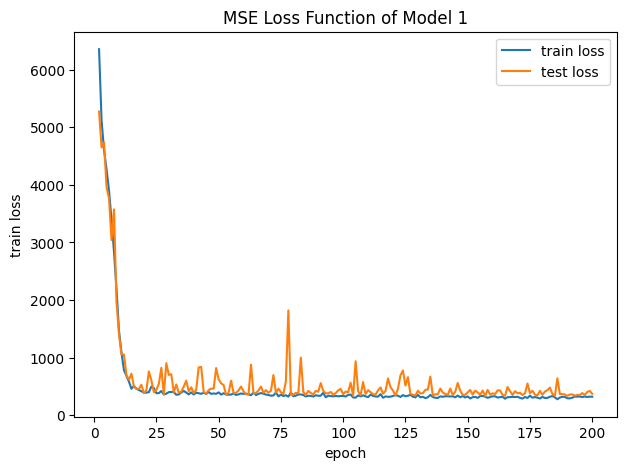

In [173]:
# Plotting the loss function of the fully connected model per epoch:

sns.lineplot(x='epoch', y='train loss', data=fc_1_results[1:], label='train loss')
sns.lineplot(x='epoch', y='test loss', data=fc_1_results[1:], label='test loss')
plt.title('MSE Loss Function of Model 1')
plt.gcf().set_size_inches(7, 5)
plt.show()

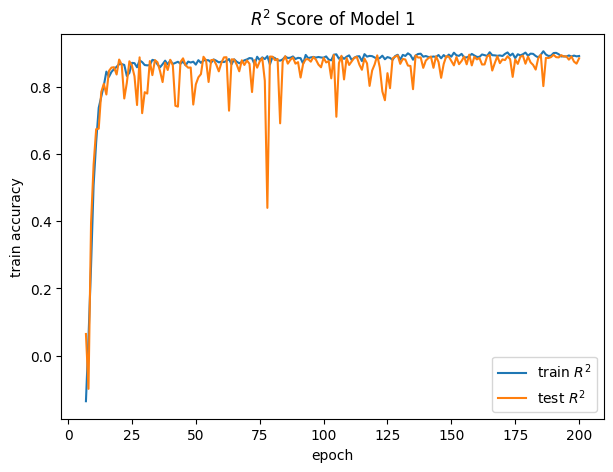

In [174]:
# Plotting the R^2 score of the fully connected model per epoch:

sns.lineplot(x='epoch', y='train accuracy', data=fc_1_results[6:], label=r'train $R^2$')
sns.lineplot(x='epoch', y='test accuracy', data=fc_1_results[6:], label=r'test $R^2$')
plt.title(r'$R^2$ Score of Model 1')
plt.gcf().set_size_inches(7, 5)
plt.show()

In [176]:
n_features = 8  # Number of features
n_targets = 1   # Number of targets

n_neurons = 64  # Number of neurons used in hidden layers

eta=0.001       # Learning rate

#del model_2
model_2 = nn.Sequential(
    nn.Linear(n_features,  n_neurons),   # From input layer to hidden layer 1
    nn.Tanh(),                           # Applying tanh activation function
    nn.Linear(n_neurons,  n_neurons),    # From hidde layer 1 to hidden layer 2
    nn.Tanh(),                           # Applying tanh activation function 
    nn.Linear(n_neurons,  n_neurons),    # From hidde layer 2 to hidden layer 3
    nn.Tanh(),                           # Applying tanh activation function
    nn.Linear(n_neurons,  n_targets),    # From hidde layer 3 to output layer 
)

optimizer = torch.optim.Adam(model_2.parameters(), lr=eta)    # Adam optimizer 

loss_func = nn.MSELoss()                 # We choose the loss function to be MSE

In [ ]:
# Training the model and collect the relevant performance metrics 

fc_2_results = train_simple_network_alt(model_2, optimizer, loss_func, eta, train_loader, test_loader, 
                         score_funcs={'accuracy':r2_score}, epochs=200)

In [178]:
# Displaying the calculated metrics

fc_2_results[-10:]

,epoch,total time,train loss,test loss,train accuracy,test accuracy
190,191,92.954442,192.444511,413.891648,0.935649,0.872691
191,192,93.298492,195.608321,228.343111,0.934591,0.929764
192,193,93.606753,99.294538,226.696521,0.966797,0.930270
193,194,94.205502,139.731289,167.267544,0.953276,0.948550
194,195,94.930102,141.397522,303.761104,0.952718,0.906566
195,196,95.423865,103.407102,157.301881,0.965422,0.951615
196,197,95.720979,80.660224,246.954528,0.973028,0.924039
197,198,96.422122,110.410596,157.947385,0.963080,0.951417
198,199,96.932762,135.089449,264.428995,0.954828,0.918664
199,200,97.372490,151.190658,416.554784,0.949444,0.871871


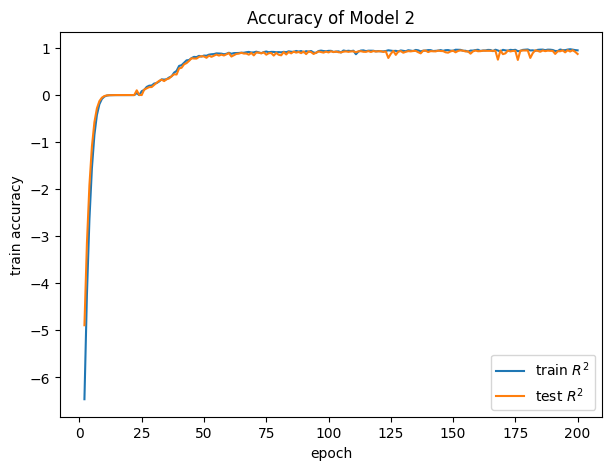

In [179]:
# Plotting the accuracy of model 3:

sns.lineplot(x='epoch', y='train accuracy', data=fc_2_results[1:], label=r'train $R^2$')
sns.lineplot(x='epoch', y='test accuracy', data=fc_2_results[1:], label=r'test $R^2$')
plt.title('Accuracy of Model 2')
plt.gcf().set_size_inches(7, 5)
plt.show()